In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
print(os.listdir('/content/drive/MyDrive/'))


['flight_folder', 'credit_risk_assessment']


Importing libraries and Global Configurations

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

#  Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

# Colour palette used throughout
BLUE, RED, GREEN, ORANGE = '#2563EB', '#DC2626', '#16A34A', '#EA580C'

#  File paths
DATA_DIR      = Path('/content/drive/MyDrive/flight_folder')
FLIGHTS_PATH  = DATA_DIR / 'flights.csv'
AIRLINES_PATH = DATA_DIR / 'airlines.csv'
AIRPORTS_PATH = DATA_DIR / 'airports.csv'

print('Setup complete ')

Setup complete 


SECTION 1: DATA LOADING & INITIAL INSPECTION

The flights table is 550 MB uncompressed.
Pre-specifying dtype for every column:
  Halves memory usage (int16 instead of int64, float32 vs float64) and also
  prevents silent type coercion that corrupts categorical codes.

In [5]:
#  Define dtype map & load CSVs
DTYPE_MAP = {
    'YEAR'               : 'int16',
    'MONTH'              : 'int8',
    'DAY'                : 'int8',
    'DAY_OF_WEEK'        : 'int8',
    'AIRLINE'            : 'category',
    'FLIGHT_NUMBER'      : 'int16',
    'TAIL_NUMBER'        : 'object',
    'ORIGIN_AIRPORT'     : 'category',
    'DESTINATION_AIRPORT': 'category',
    'SCHEDULED_DEPARTURE': 'float32',
    'DEPARTURE_TIME'     : 'float32',
    'DEPARTURE_DELAY'    : 'float32',
    'TAXI_OUT'           : 'float32',
    'WHEELS_OFF'         : 'float32',
    'SCHEDULED_TIME'     : 'float32',
    'ELAPSED_TIME'       : 'float32',
    'AIR_TIME'           : 'float32',
    'DISTANCE'           : 'float32',
    'WHEELS_ON'          : 'float32',
    'TAXI_IN'            : 'float32',
    'SCHEDULED_ARRIVAL'  : 'float32',
    'ARRIVAL_TIME'       : 'float32',
    'ARRIVAL_DELAY'      : 'float32',
    'DIVERTED'           : 'int8',
    'CANCELLED'          : 'int8',
    'CANCELLATION_REASON': 'category',
    'AIR_SYSTEM_DELAY'   : 'float32',
    'SECURITY_DELAY'     : 'float32',
    'AIRLINE_DELAY'      : 'float32',
    'LATE_AIRCRAFT_DELAY': 'float32',
    'WEATHER_DELAY'      : 'float32',
}

df_raw      = pd.read_csv(FLIGHTS_PATH,  dtype=DTYPE_MAP, low_memory=False)
df_airlines = pd.read_csv(AIRLINES_PATH, dtype={'IATA_CODE': 'category', 'AIRLINE': 'object'})
df_airports = pd.read_csv(AIRPORTS_PATH, dtype={'IATA_CODE': 'category'})

print(f'Flights shape  : {df_raw.shape}')
print(f'Airlines shape : {df_airlines.shape}')
print(f'Airports shape : {df_airports.shape}')

Flights shape  : (5819079, 31)
Airlines shape : (14, 2)
Airports shape : (322, 7)


In [6]:
# look: head, dtypes, memory
print('First 5 rows')
display(df_raw.head())

print('\nData types')
display(df_raw.dtypes.to_frame('dtype'))

print('\nMemory usage')
mem = df_raw.memory_usage(deep=True)
print(f'Total: {mem.sum() / 1e6:.1f} MB')
display(
    mem.to_frame('bytes')
       .assign(MB=lambda x: x['bytes'] / 1e6)
       .sort_values('MB', ascending=False)
       .head(10))

First 5 rows


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5.0,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10.0,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20.0,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20.0,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25.0,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN



Data types


,dtype
YEAR,int16
MONTH,int8
DAY,int8
DAY_OF_WEEK,int8
AIRLINE,category
FLIGHT_NUMBER,int16
TAIL_NUMBER,object
ORIGIN_AIRPORT,category
DESTINATION_AIRPORT,category
SCHEDULED_DEPARTURE,float32



Memory usage
Total: 849.3 MB


,bytes,MB
TAIL_NUMBER,319695659,319.695659
TAXI_OUT,23276316,23.276316
SCHEDULED_TIME,23276316,23.276316
WHEELS_OFF,23276316,23.276316
DEPARTURE_DELAY,23276316,23.276316
DEPARTURE_TIME,23276316,23.276316
SCHEDULED_DEPARTURE,23276316,23.276316
AIR_SYSTEM_DELAY,23276316,23.276316
ARRIVAL_DELAY,23276316,23.276316
ARRIVAL_TIME,23276316,23.276316


SECTION 2: MERGING WITH LOOKUP TABLES

Rename lookup columns & merge ,
origin / destination city-state pairs via left joins and we validate coverage after every join to catch unmatched codes.

In [7]:
# Rename to avoid column name collisions after the merge
df_airlines = df_airlines.rename(columns={
    'IATA_CODE': 'AIRLINE',
    'AIRLINE'  : 'AIRLINE_NAME'
})

df_airports_orig = df_airports.rename(columns={
    'IATA_CODE': 'ORIGIN_AIRPORT',
    'CITY'     : 'ORIGIN_CITY',
    'STATE'    : 'ORIGIN_STATE',
    'AIRPORT'  : 'ORIGIN_AIRPORT_NAME',
    'LATITUDE' : 'ORIGIN_LAT',
    'LONGITUDE': 'ORIGIN_LON',
})[['ORIGIN_AIRPORT','ORIGIN_CITY','ORIGIN_STATE',
    'ORIGIN_AIRPORT_NAME','ORIGIN_LAT','ORIGIN_LON']]

df_airports_dest = df_airports.rename(columns={
    'IATA_CODE': 'DESTINATION_AIRPORT',
    'CITY'     : 'DEST_CITY',
    'STATE'    : 'DEST_STATE',
    'AIRPORT'  : 'DEST_AIRPORT_NAME',
    'LATITUDE' : 'DEST_LAT',
    'LONGITUDE': 'DEST_LON',
})[['DESTINATION_AIRPORT','DEST_CITY','DEST_STATE',
    'DEST_AIRPORT_NAME','DEST_LAT','DEST_LON']]

# Chain all three left joins
df = (
    df_raw
    .merge(df_airlines,      on='AIRLINE',             how='left')
    .merge(df_airports_orig, on='ORIGIN_AIRPORT',      how='left')
    .merge(df_airports_dest, on='DESTINATION_AIRPORT', how='left')
)

# Coverage validation — any NaN here means an unmatched IATA code
print(f'Rows after merge    : {len(df):,}  (expected {len(df_raw):,})')
print(f'Unmatched AIRLINE   : {df["AIRLINE_NAME"].isna().sum():,}')
print(f'Unmatched ORIGIN    : {df["ORIGIN_CITY"].isna().sum():,}')
print(f'Unmatched DEST      : {df["DEST_CITY"].isna().sum():,}')

# Remove any duplicate rows that many-to-many joins can introduce
before = len(df)
df = df.drop_duplicates()
print(f'Duplicate rows removed: {before - len(df):,}')

Rows after merge    : 5,819,079  (expected 5,819,079)
Unmatched AIRLINE   : 0
Unmatched ORIGIN    : 486,165
Unmatched DEST      : 486,165
Duplicate rows removed: 0


 SECTION 3: PREPROCESSING & CLEANING

Columns with missing values: 28


,missing_count,pct
CANCELLATION_REASON,5729195,98.46%
AIRLINE_DELAY,4755640,81.72%
AIR_SYSTEM_DELAY,4755640,81.72%
SECURITY_DELAY,4755640,81.72%
WEATHER_DELAY,4755640,81.72%
LATE_AIRCRAFT_DELAY,4755640,81.72%
DEST_LAT,490775,8.43%
DEST_LON,490775,8.43%
ORIGIN_LON,490770,8.43%
ORIGIN_LAT,490770,8.43%


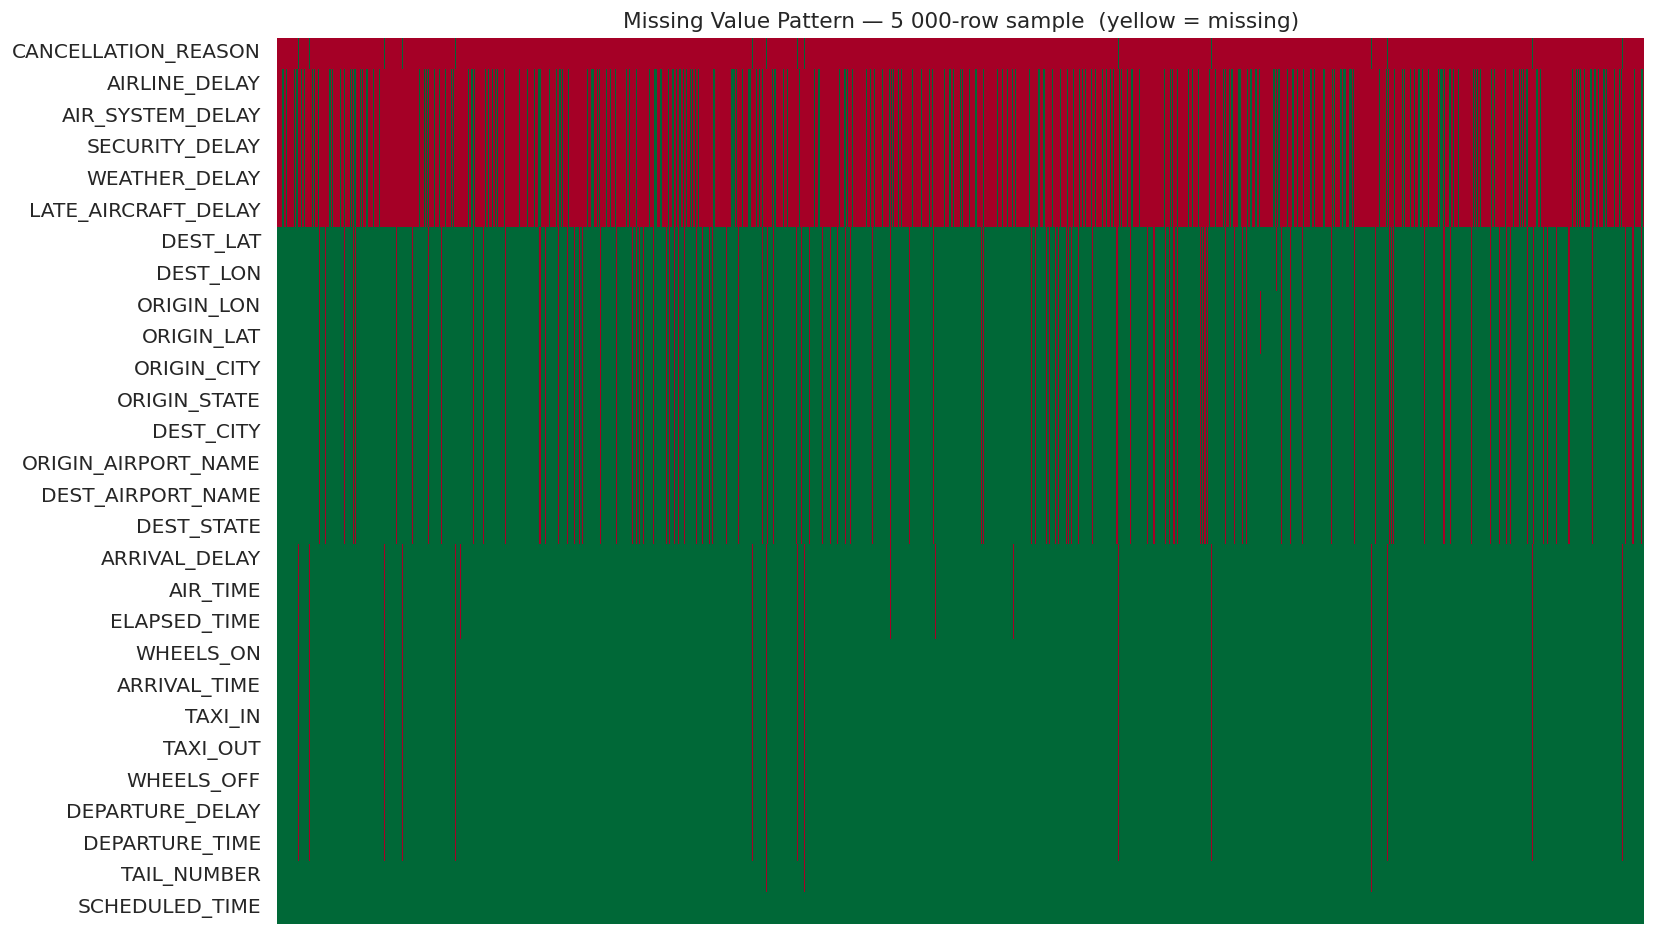

In [8]:
# Missing value analysis & heatmap
missing = (
    df.isnull().sum()
      .to_frame('missing_count')
      .assign(pct=lambda x: 100 * x['missing_count'] / len(df))
      .query('missing_count > 0')
      .sort_values('pct', ascending=False)
)

print(f'Columns with missing values: {len(missing)}')
display(
    missing.style
           .background_gradient(cmap='Reds', subset=['pct'])
           .format({'pct': '{:.2f}%'})
)

# Visual pattern map (5 000-row sample for speed)
fig, ax = plt.subplots(figsize=(14, 8))
sample_miss = df[missing.index].sample(min(5000, len(df)), random_state=42).isnull()
sns.heatmap(sample_miss.T, cbar=False, yticklabels=True,
            xticklabels=False, cmap='RdYlGn_r', ax=ax)
ax.set_title('Missing Value Pattern — 5 000-row sample  (yellow = missing)',
             fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
df['FLIGHT_DATE'] = pd.to_datetime(
    df[['YEAR','MONTH','DAY']].rename(columns={'YEAR':'year','MONTH':'month','DAY':'day'}),
    errors='coerce'
)

# Impute delay components NaN → 0
# Delay component columns are only populated when a delay exists.
# NaN means "zero minutes of that delay type" — not unknown.
DELAY_COMPONENTS = [
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]
df[DELAY_COMPONENTS] = df[DELAY_COMPONENTS].fillna(0)

print('Remaining NaNs in delay components:',
      df[DELAY_COMPONENTS].isnull().sum().sum())

Remaining NaNs in delay components: 0


In [10]:
# Separate cancelled / diverted / operated flights
# Cancelled and diverted flights have no valid arrival delay.
# Keep them in dedicated DataFrames for independent analysis.
df_cancelled = df[df['CANCELLED'] == 1].copy()
df_diverted  = df[(df['DIVERTED'] == 1) & (df['CANCELLED'] == 0)].copy()
df_operated  = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()

total = len(df)
print(f'Total flights        : {total:>9,}')
print(f'Operated (for EDA)   : {len(df_operated):>9,}  ({100*len(df_operated)/total:.1f}%)')
print(f'Cancelled            : {len(df_cancelled):>9,}  ({100*len(df_cancelled)/total:.1f}%)')
print(f'Diverted             : {len(df_diverted):>9,}  ({100*len(df_diverted)/total:.1f}%)')

Total flights        : 5,819,079
Operated (for EDA)   : 5,714,008  (98.2%)
Cancelled            :    89,884  (1.5%)
Diverted             :    15,187  (0.3%)


In [11]:
# Datetime conversion & temporal features
def hhmm_to_hours(series: pd.Series) -> pd.Series:
    """Convert HHMM integer (e.g. 1435) → decimal hour (0–23.99)."""
    s = series.fillna(0).astype(int)
    return (s // 100) + (s % 100) / 60

df_operated = df_operated.copy()

# Proper date column
df_operated['FLIGHT_DATE'] = pd.to_datetime(
    df_operated[['YEAR','MONTH','DAY']]
    .rename(columns={'YEAR':'year','MONTH':'month','DAY':'day'})
)

# Hour-of-day features
df_operated['DEP_HOUR'] = hhmm_to_hours(df_operated['SCHEDULED_DEPARTURE']).astype('float32')
df_operated['ARR_HOUR'] = hhmm_to_hours(df_operated['SCHEDULED_ARRIVAL']).astype('float32')

# Named day of week
DOW_MAP = {1:'Monday',2:'Tuesday',3:'Wednesday',4:'Thursday',
           5:'Friday',6:'Saturday',7:'Sunday'}
df_operated['DOW_NAME'] = df_operated['DAY_OF_WEEK'].map(DOW_MAP).astype('category')

print('Datetime features added. Sample:')
display(df_operated[['FLIGHT_DATE','DEP_HOUR','ARR_HOUR','DOW_NAME']].head(3))

Datetime features added. Sample:


,FLIGHT_DATE,DEP_HOUR,ARR_HOUR,DOW_NAME
0,2015-01-01,0.083333,4.500000,Thursday
1,2015-01-01,0.166667,7.833333,Thursday
2,2015-01-01,0.333333,8.100000,Thursday


 SECTION 4: FEATURE ENGINEERING  

In [12]:
# Core features
# Target variable: is_delayed = 1 if arrival > 15 min late
df_operated['IS_DELAYED'] = (df_operated['ARRIVAL_DELAY'] > 15).astype('int8')

# Weekend flag
df_operated['IS_WEEKEND'] = df_operated['DAY_OF_WEEK'].isin([6, 7]).astype('int8')

# Actual vs. scheduled flight duration difference
df_operated['DURATION_DIFF'] = (
    df_operated['ELAPSED_TIME'] - df_operated['SCHEDULED_TIME']
).astype('float32')

# Route label  e.g. "LAX→JFK"
df_operated['ROUTE'] = (
    df_operated['ORIGIN_AIRPORT'].astype(str) + '→' +
    df_operated['DESTINATION_AIRPORT'].astype(str)
).astype('category')

# Departure time bucket (5 named periods)
bins   = [0,  6,  12, 17, 21, 24]
labels = ['Red-Eye (0–6)', 'Morning (6–12)', 'Afternoon (12–17)',
          'Evening (17–21)', 'Night (21–24)']
df_operated['DEP_PERIOD'] = pd.cut(
    df_operated['DEP_HOUR'], bins=bins, labels=labels, right=False
).astype('category')

print('Core features created: IS_DELAYED, IS_WEEKEND, DURATION_DIFF, ROUTE, DEP_PERIOD')
print(f'\nClass balance — IS_DELAYED:')
print(df_operated['IS_DELAYED'].value_counts(normalize=True).mul(100).round(1))

Core features created: IS_DELAYED, IS_WEEKEND, DURATION_DIFF, ROUTE, DEP_PERIOD

Class balance — IS_DELAYED:
IS_DELAYED
0    82.1
1    17.9
Name: proportion, dtype: float64


In [13]:
# Network effect features
# Expanding mean delay per origin airport / airline, shifted by 1 flight
# This ensures zero data leakage into the target variable.
df_operated = df_operated.sort_values('FLIGHT_DATE')

df_operated['ORIGIN_AVG_DELAY'] = (
    df_operated.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY']
    .transform(lambda x: x.expanding().mean().shift(1))
).astype('float32')

df_operated['AIRLINE_AVG_DELAY'] = (
    df_operated.groupby('AIRLINE')['ARRIVAL_DELAY']
    .transform(lambda x: x.expanding().mean().shift(1))
).astype('float32')

print('Network effect features created: ORIGIN_AVG_DELAY, AIRLINE_AVG_DELAY')
display(df_operated[['ORIGIN_AIRPORT','ORIGIN_AVG_DELAY',
                      'AIRLINE','AIRLINE_AVG_DELAY']].dropna().head(5))

Network effect features created: ORIGIN_AVG_DELAY, AIRLINE_AVG_DELAY


,ORIGIN_AIRPORT,ORIGIN_AVG_DELAY,AIRLINE,AIRLINE_AVG_DELAY
9363,LAS,-23.000000,WN,26.000000
9364,LAS,-14.000000,WN,15.666667
9365,LAS,-6.333333,WN,14.000000
9383,DFW,27.000000,AA,17.400000
9342,DFW,29.000000,OO,19.000000


SECTION 5: EXPLORATORY DATA ANALYSIS   

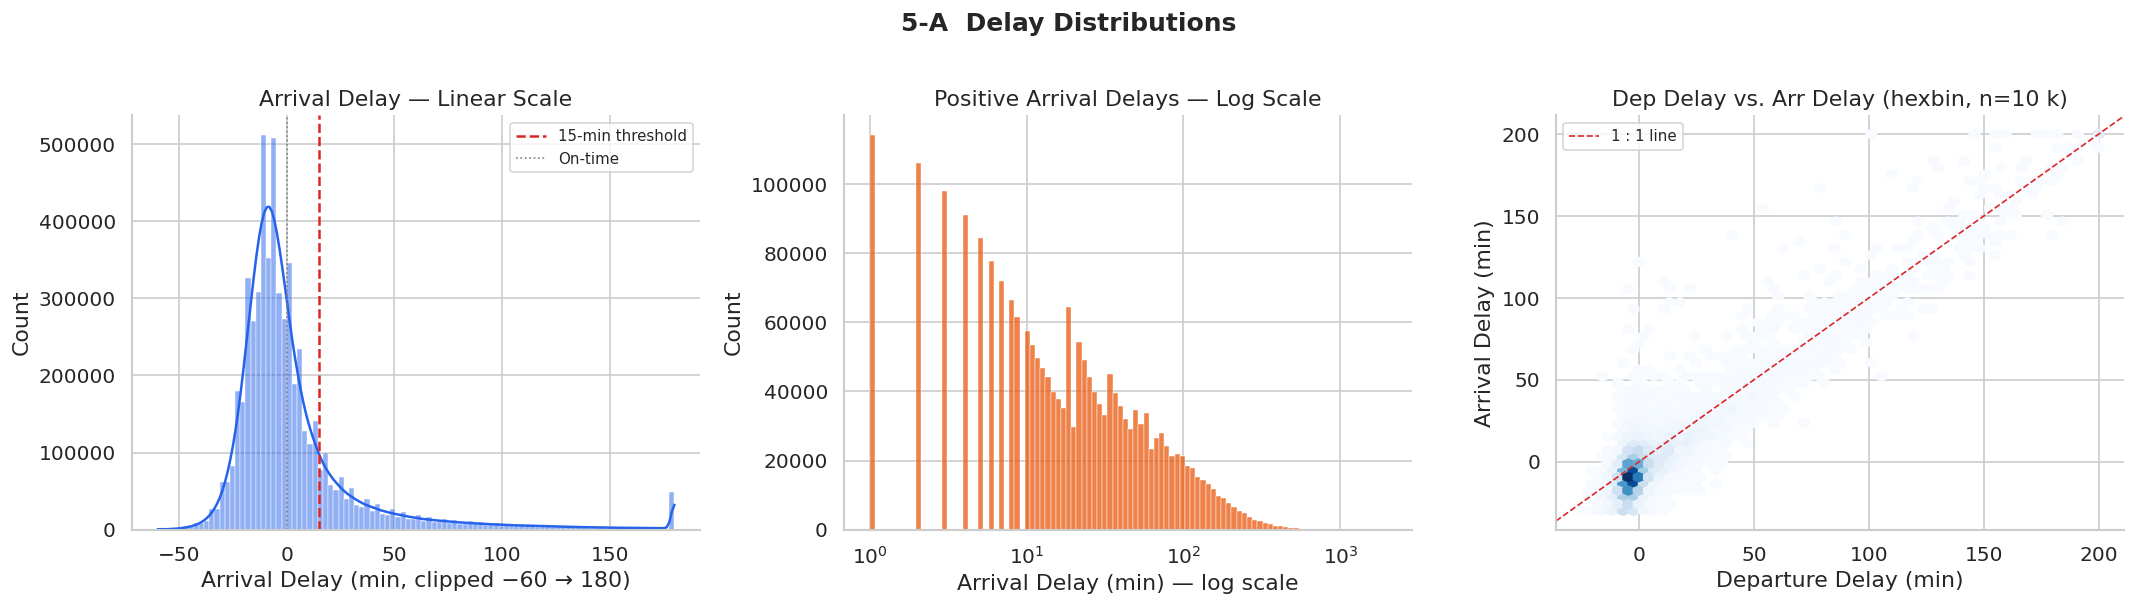

Arrival Delay — mean : 4.4 min  |  median : -5.0 min  |  95th pct : 66 min


In [14]:
# Univariate — delay distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear-scale histogram (clipped for readability)
ax = axes[0]
clip = df_operated['ARRIVAL_DELAY'].clip(-60, 180)
sns.histplot(clip, bins=100, color=BLUE, ax=ax, kde=True)
ax.axvline(15,  color=RED,    ls='--', lw=1.5, label='15-min threshold')
ax.axvline(0,   color='grey', ls=':',  lw=1,   label='On-time')
ax.set_xlabel('Arrival Delay (min, clipped −60 → 180)')
ax.set_title('Arrival Delay — Linear Scale')
ax.legend(fontsize=9)

# Log-scale — reveals tail shape
ax = axes[1]
pos_delay = df_operated.loc[df_operated['ARRIVAL_DELAY'] > 0, 'ARRIVAL_DELAY']
sns.histplot(pos_delay, bins=100, log_scale=True, color=ORANGE, ax=ax)
ax.set_xlabel('Arrival Delay (min) — log scale')
ax.set_title('Positive Arrival Delays — Log Scale')

# Hexbin: departure delay vs. arrival delay
ax = axes[2]
sample = (df_operated[['DEPARTURE_DELAY','ARRIVAL_DELAY']]
          .dropna().sample(10_000, random_state=42))
ax.hexbin(sample['DEPARTURE_DELAY'].clip(-30, 200),
          sample['ARRIVAL_DELAY'].clip(-30, 200),
          gridsize=50, cmap='Blues', mincnt=1)
ax.axline((0,0), slope=1, color=RED, ls='--', lw=1, label='1 : 1 line')
ax.set_xlabel('Departure Delay (min)')
ax.set_ylabel('Arrival Delay (min)')
ax.set_title('Dep Delay vs. Arr Delay (hexbin, n=10 k)')
ax.legend(fontsize=9)

fig.suptitle('5-A  Delay Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Arrival Delay — mean : {df_operated['ARRIVAL_DELAY'].mean():.1f} min  |"
      f"  median : {df_operated['ARRIVAL_DELAY'].median():.1f} min  |"
      f"  95th pct : {df_operated['ARRIVAL_DELAY'].quantile(0.95):.0f} min")

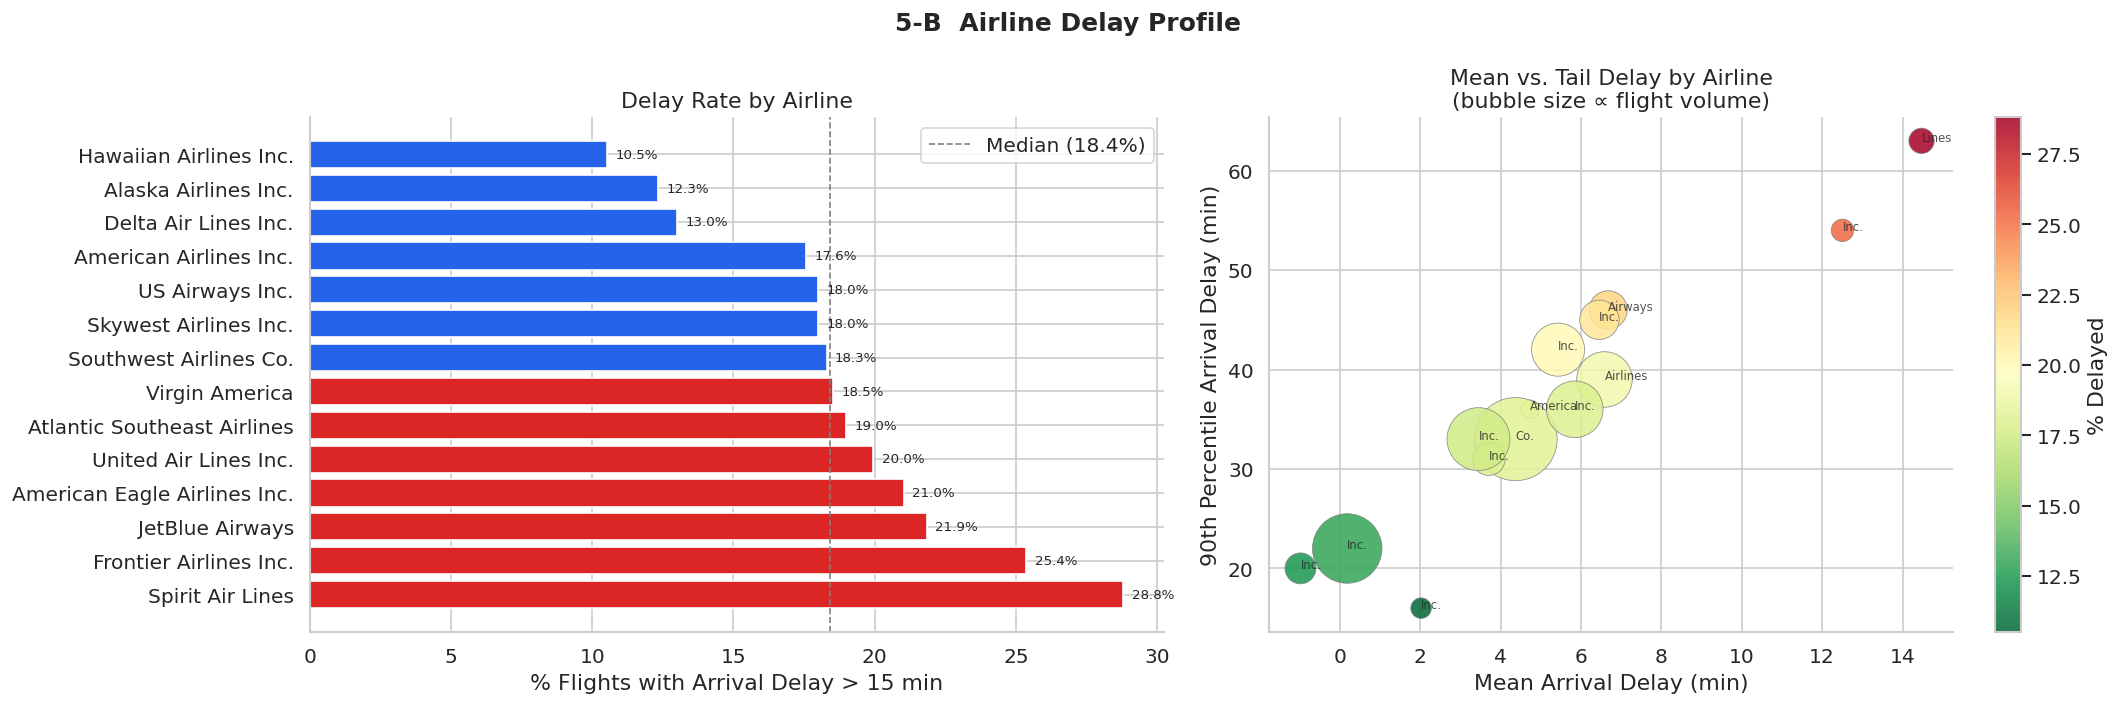

,total_flights,pct_delayed,avg_arr_delay,p90_arr_delay
AIRLINE_NAME,,,,
Spirit Air Lines,"115,193",28.8%,14.5,63
Frontier Airlines Inc.,"90,090",25.4%,12.5,54
JetBlue Airways,"262,042",21.9%,6.7,46
American Eagle Airlines Inc.,"278,791",21.0%,6.5,45
United Air Lines Inc.,"507,762",20.0%,5.4,42
Atlantic Southeast Airlines,"554,752",19.0%,6.6,39
Virgin America,"61,248",18.5%,4.7,36
Southwest Airlines Co.,"1,242,403",18.3%,4.4,33
Skywest Airlines Inc.,"576,814",18.0%,5.8,36


In [15]:
# Bivariate — delay frequency by airline
airline_stats = (
    df_operated
    .groupby('AIRLINE_NAME', observed=True)
    .agg(
        total_flights = ('IS_DELAYED', 'count'),
        pct_delayed   = ('IS_DELAYED', 'mean'),
        avg_arr_delay = ('ARRIVAL_DELAY', 'mean'),
        p90_arr_delay = ('ARRIVAL_DELAY', lambda x: x.quantile(0.90)),
    )
    .assign(pct_delayed=lambda x: x['pct_delayed'] * 100)
    .sort_values('pct_delayed', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Horizontal bar — % delayed per airline
ax = axes[0]
median_rate = airline_stats['pct_delayed'].median()
colors = [RED if v > median_rate else BLUE for v in airline_stats['pct_delayed']]
bars = ax.barh(airline_stats.index, airline_stats['pct_delayed'], color=colors)
ax.axvline(median_rate, color='grey', ls='--', lw=1, label=f'Median ({median_rate:.1f}%)')
ax.set_xlabel('% Flights with Arrival Delay > 15 min')
ax.set_title('Delay Rate by Airline')
ax.legend()
for bar, val in zip(bars, airline_stats['pct_delayed']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

# Bubble chart — mean vs. tail delay, bubble = flight volume
ax = axes[1]
sc = ax.scatter(
    airline_stats['avg_arr_delay'],
    airline_stats['p90_arr_delay'],
    s=airline_stats['total_flights'] / 500,
    c=airline_stats['pct_delayed'],
    cmap='RdYlGn_r', alpha=0.85, edgecolors='grey', linewidths=0.5
)
plt.colorbar(sc, ax=ax, label='% Delayed')
for _, row in airline_stats.iterrows():
    ax.annotate(row.name.split()[-1],
                (row['avg_arr_delay'], row['p90_arr_delay']),
                fontsize=7, alpha=0.8)
ax.set_xlabel('Mean Arrival Delay (min)')
ax.set_ylabel('90th Percentile Arrival Delay (min)')
ax.set_title('Mean vs. Tail Delay by Airline\n(bubble size ∝ flight volume)')

fig.suptitle('5-B  Airline Delay Profile', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
display(
    airline_stats.style
    .format({'pct_delayed':'{:.1f}%','avg_arr_delay':'{:.1f}',
             'p90_arr_delay':'{:.0f}','total_flights':'{:,}'})
    .background_gradient(cmap='RdYlGn_r', subset=['pct_delayed','avg_arr_delay'])
)

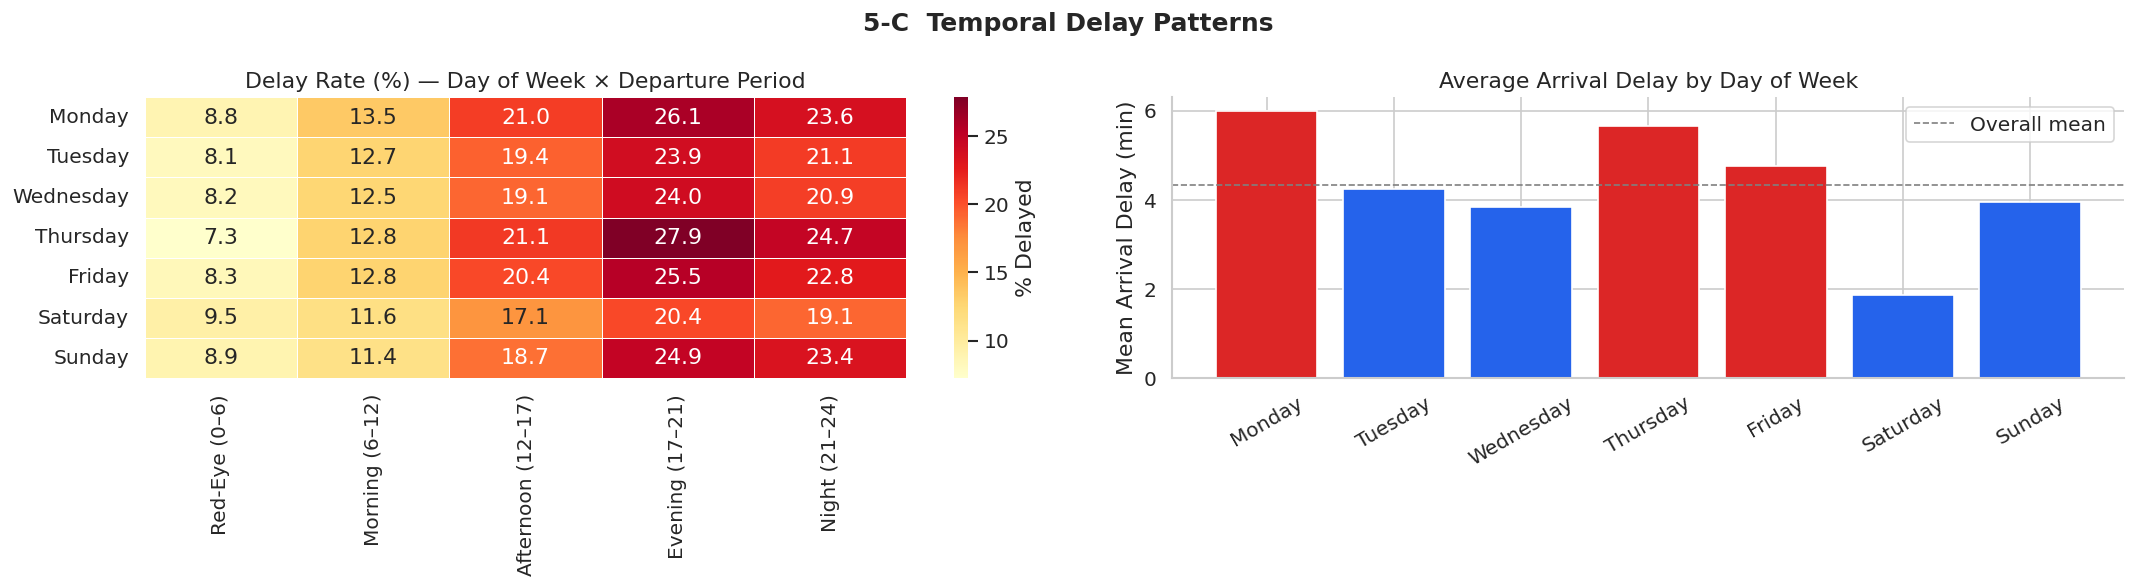

In [16]:
# Day of week × departure period heatmap
DOW_ORDER    = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
PERIOD_ORDER = ['Red-Eye (0–6)','Morning (6–12)','Afternoon (12–17)',
                'Evening (17–21)','Night (21–24)']

pivot = (
    df_operated
    .groupby(['DOW_NAME','DEP_PERIOD'], observed=True)['IS_DELAYED']
    .mean()
    .mul(100)
    .reset_index()
    .pivot(index='DOW_NAME', columns='DEP_PERIOD', values='IS_DELAYED')
    .reindex(index=DOW_ORDER, columns=PERIOD_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Heatmap
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': '% Delayed'})
axes[0].set_title('Delay Rate (%) — Day of Week × Departure Period')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# Day-of-week bar
dow_avg    = (df_operated.groupby('DOW_NAME', observed=True)['ARRIVAL_DELAY']
              .mean().reindex(DOW_ORDER))
color_seq  = [RED if v > dow_avg.mean() else BLUE for v in dow_avg]
axes[1].bar(dow_avg.index, dow_avg.values, color=color_seq)
axes[1].axhline(dow_avg.mean(), color='grey', ls='--', lw=1, label='Overall mean')
axes[1].set_ylabel('Mean Arrival Delay (min)')
axes[1].set_title('Average Arrival Delay by Day of Week')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

fig.suptitle('5-C  Temporal Delay Patterns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

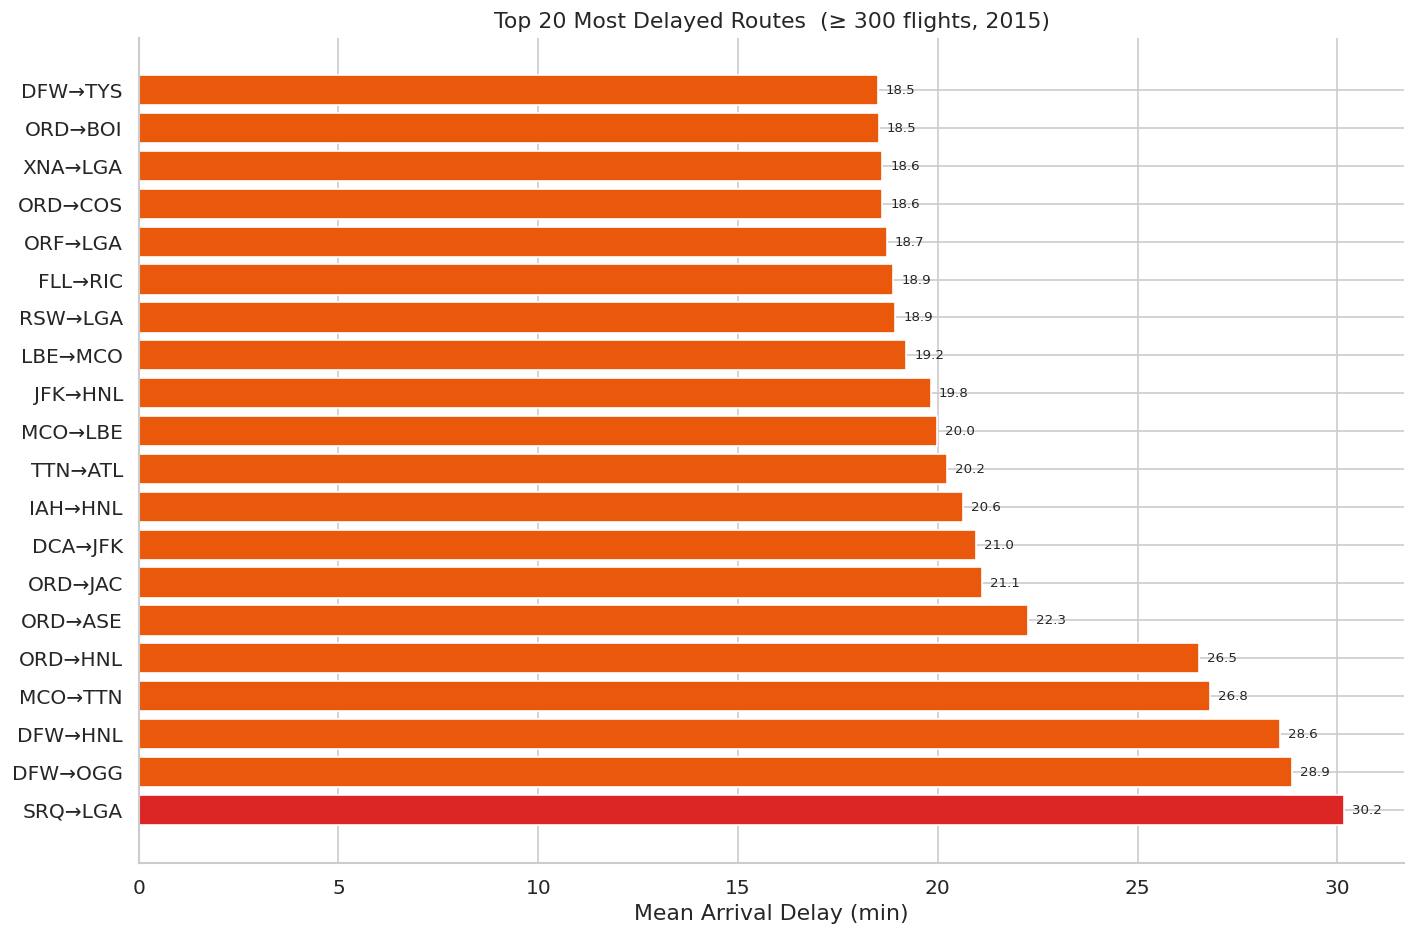

In [17]:
# Top delayed routes
route_stats = (
    df_operated
    .groupby('ROUTE', observed=True)
    .agg(
        total_flights = ('IS_DELAYED', 'count'),
        pct_delayed   = ('IS_DELAYED', 'mean'),
        avg_delay     = ('ARRIVAL_DELAY', 'mean'),
    )
    .query('total_flights >= 300')    # minimum sample size for stability
    .assign(pct_delayed=lambda x: x['pct_delayed'] * 100)
    .sort_values('avg_delay', ascending=False)
)

TOP_N = 20
top_routes = route_stats.head(TOP_N)

fig, ax = plt.subplots(figsize=(12, 8))
bar_colors = [RED if v > 30 else ORANGE for v in top_routes['avg_delay']]
bars = ax.barh(top_routes.index, top_routes['avg_delay'], color=bar_colors)
ax.set_xlabel('Mean Arrival Delay (min)')
ax.set_title(f'Top {TOP_N} Most Delayed Routes  (≥ 300 flights, 2015)')
for bar, val in zip(bars, top_routes['avg_delay']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

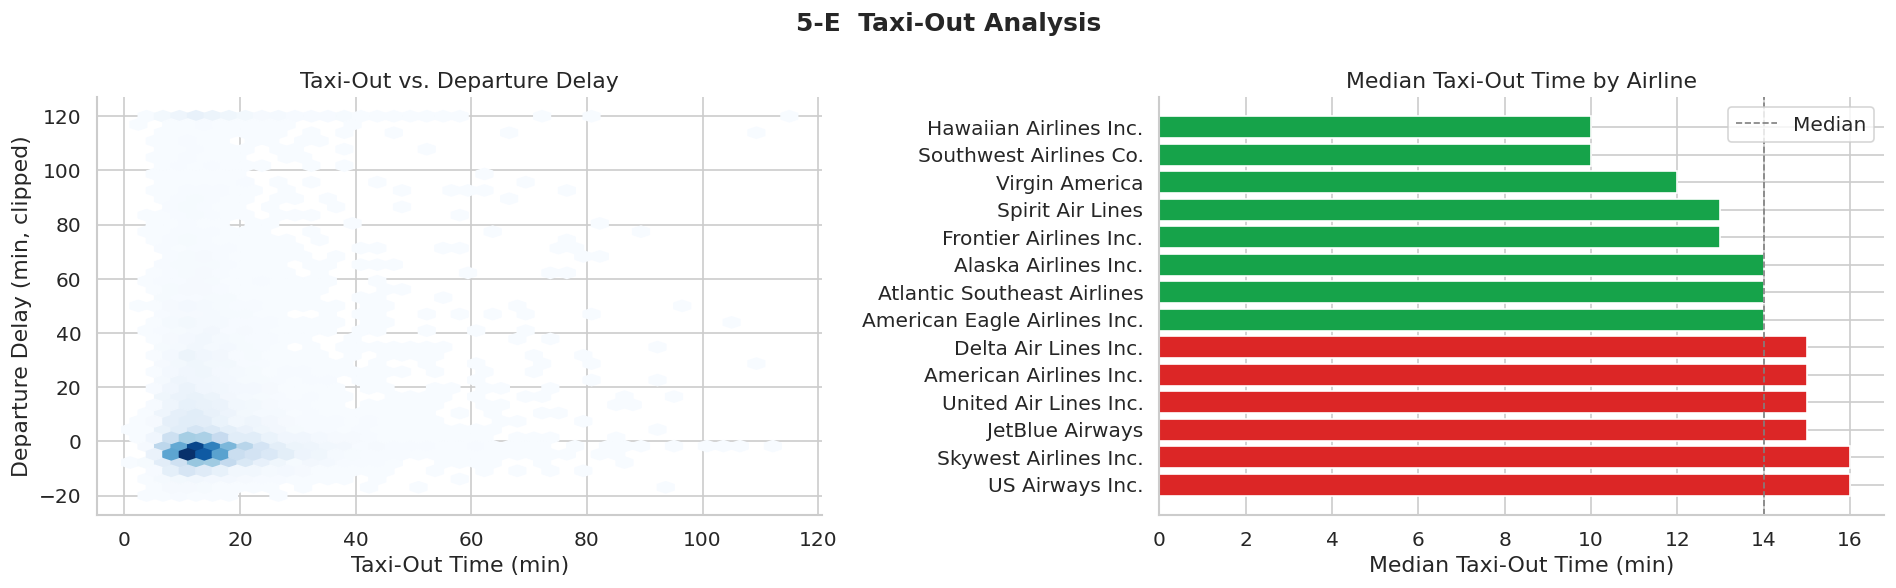

Pearson correlation  Taxi-Out ↔ Departure Delay: 0.054


In [18]:
# Taxi-out time vs. departure delay
sample_taxi = (
    df_operated[['TAXI_OUT','DEPARTURE_DELAY','AIRLINE_NAME']]
    .dropna()
    .query('TAXI_OUT > 0 and TAXI_OUT < 120')
    .sample(20_000, random_state=42)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hexbin scatter
ax = axes[0]
ax.hexbin(sample_taxi['TAXI_OUT'],
          sample_taxi['DEPARTURE_DELAY'].clip(-20, 120),
          gridsize=40, cmap='Blues', mincnt=1)
ax.set_xlabel('Taxi-Out Time (min)')
ax.set_ylabel('Departure Delay (min, clipped)')
ax.set_title('Taxi-Out vs. Departure Delay')

# Median taxi-out per airline
ax = axes[1]
taxi_by_airline = (
    df_operated.groupby('AIRLINE_NAME', observed=True)['TAXI_OUT']
    .median().sort_values(ascending=False)
)
median_taxi = taxi_by_airline.median()
colors = [RED if v > median_taxi else GREEN for v in taxi_by_airline]
ax.barh(taxi_by_airline.index, taxi_by_airline.values, color=colors)
ax.axvline(median_taxi, color='grey', ls='--', lw=1, label='Median')
ax.set_xlabel('Median Taxi-Out Time (min)')
ax.set_title('Median Taxi-Out Time by Airline')
ax.legend()

fig.suptitle('5-E  Taxi-Out Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

corr_val = sample_taxi[['TAXI_OUT','DEPARTURE_DELAY']].corr().iloc[0, 1]
print(f'Pearson correlation  Taxi-Out ↔ Departure Delay: {corr_val:.3f}')

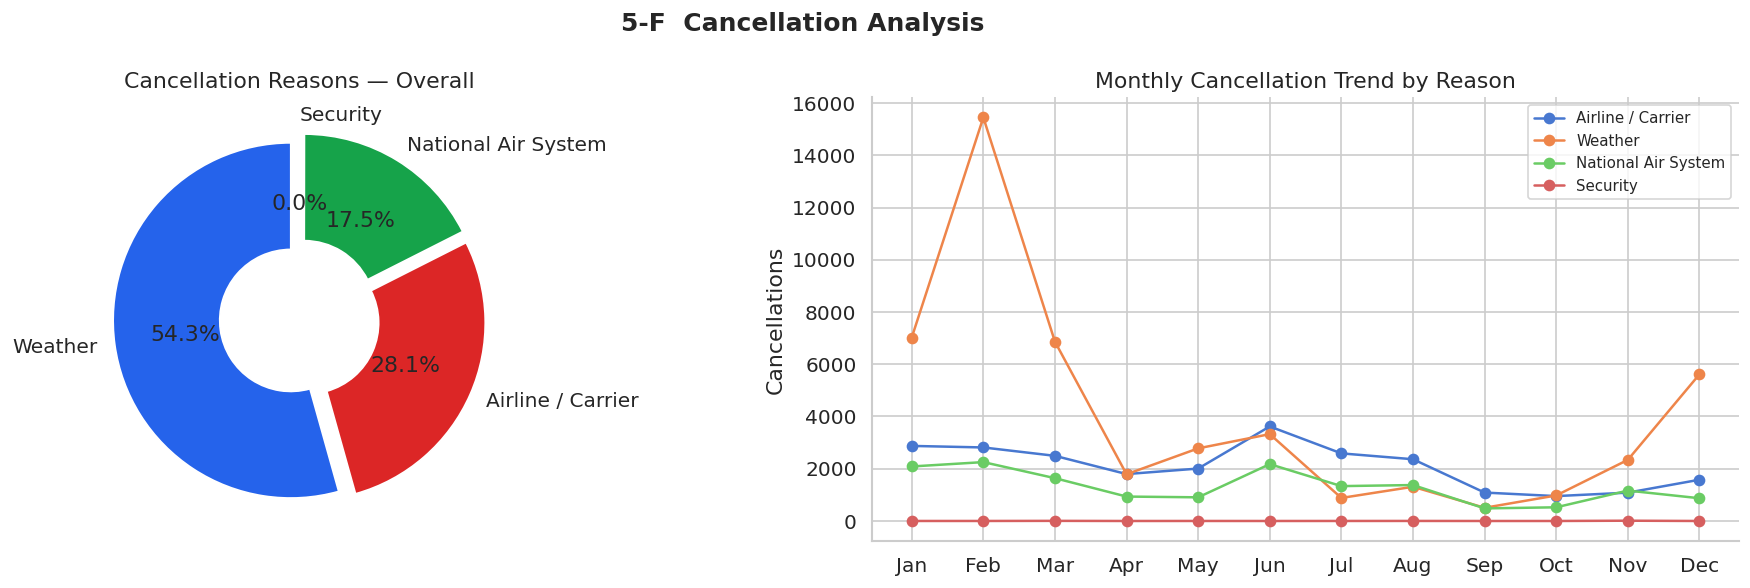

In [19]:
# Cancellation reasons
CANCEL_CODE_MAP = {
    'A': 'Airline / Carrier',
    'B': 'Weather',
    'C': 'National Air System',
    'D': 'Security'
}

cancel_counts = (
    df_cancelled['CANCELLATION_REASON']
    .map(CANCEL_CODE_MAP)
    .value_counts()
)

cancel_monthly = (
    df_cancelled
    .assign(CANCEL_LABEL=df_cancelled['CANCELLATION_REASON'].map(CANCEL_CODE_MAP))
    .groupby(['MONTH', 'CANCEL_LABEL'])
    .size()
    .reset_index(name='count')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Donut / pie
ax = axes[0]
ax.pie(cancel_counts,
       labels=cancel_counts.index,
       autopct='%1.1f%%',
       explode=[0.05] * len(cancel_counts),
       startangle=90,
       colors=['#2563EB','#DC2626','#16A34A','#9333EA'],
       wedgeprops={'width': 0.6})          # donut style
ax.set_title('Cancellation Reasons — Overall')

# Monthly line trend
ax = axes[1]
for reason, grp in cancel_monthly.groupby('CANCEL_LABEL'):
    ax.plot(grp['MONTH'], grp['count'], marker='o', label=reason)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('Cancellations')
ax.set_title('Monthly Cancellation Trend by Reason')
ax.legend(fontsize=9)

fig.suptitle('5-F  Cancellation Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

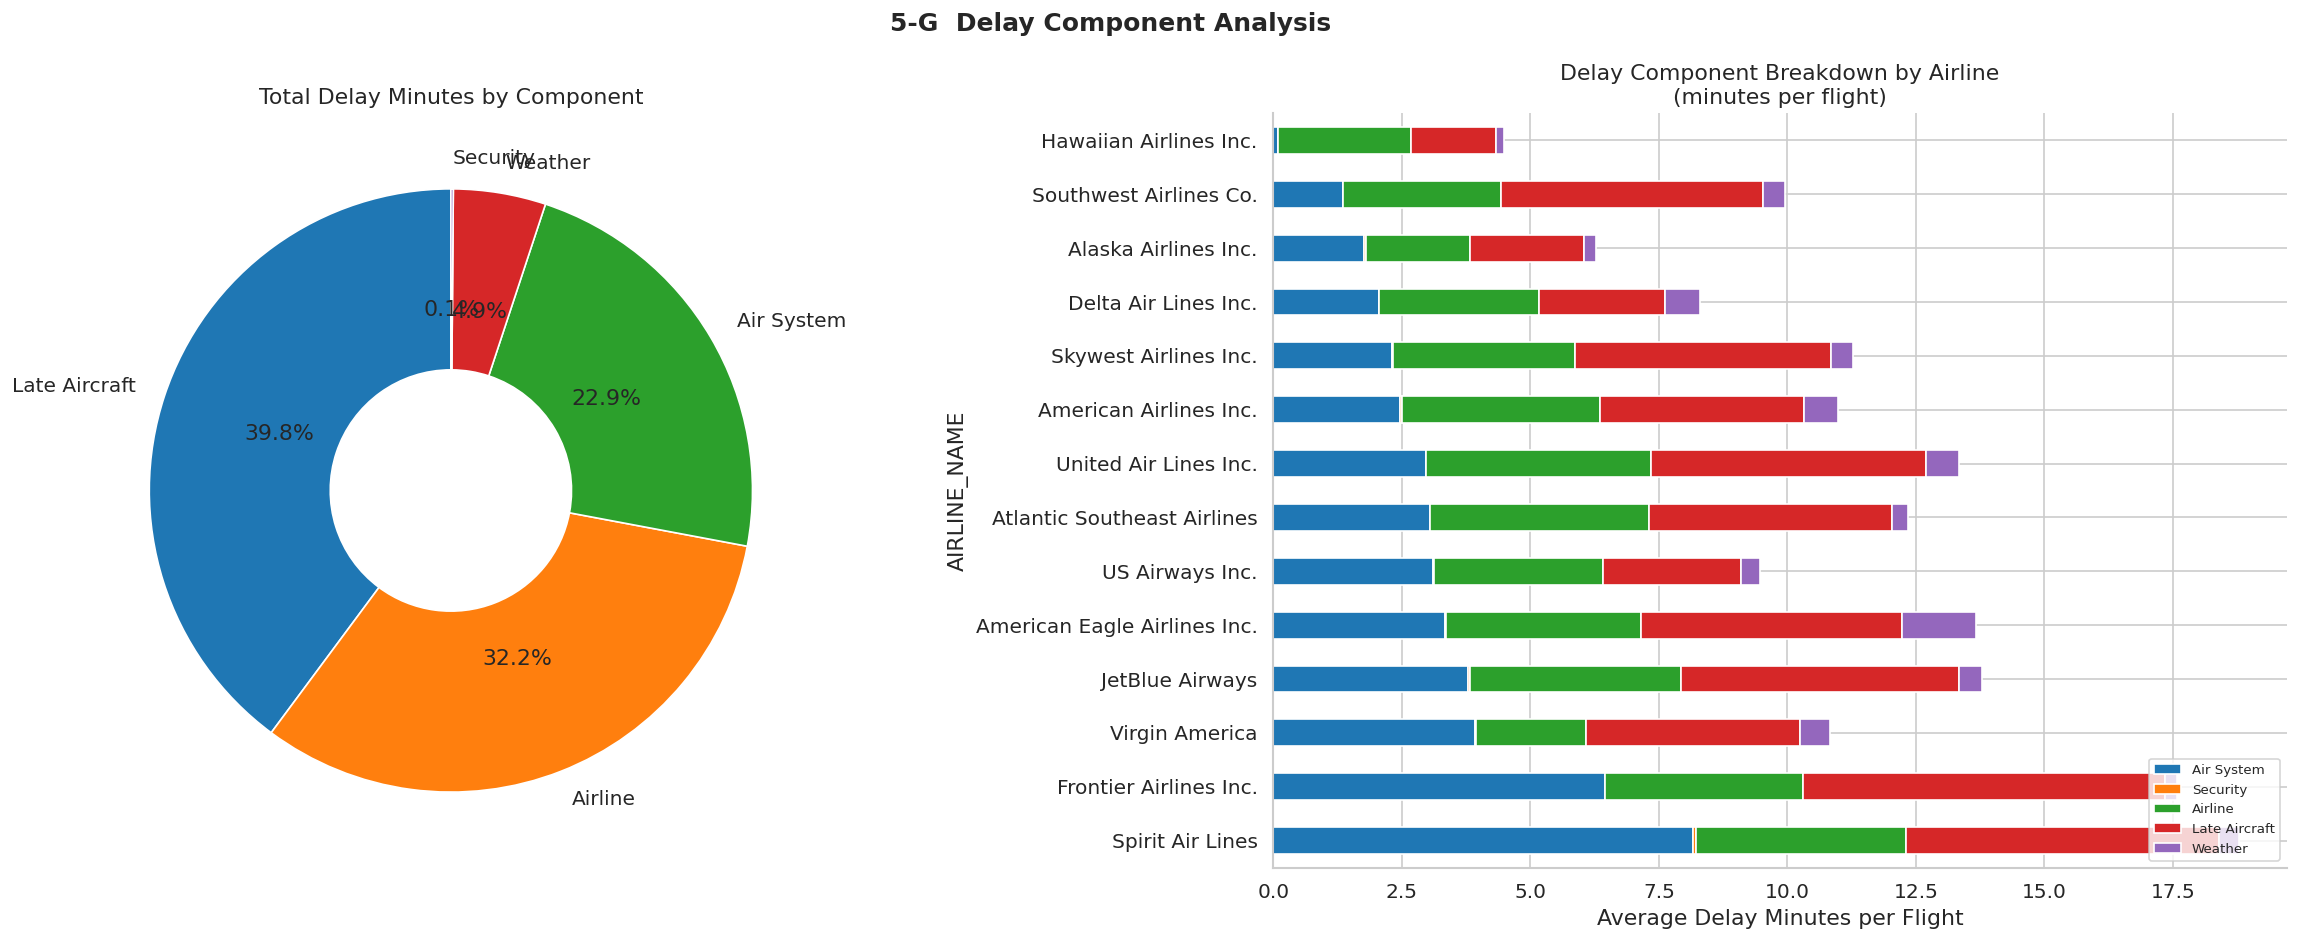

In [20]:
# Delay component breakdown
delay_totals = (
    df_operated[DELAY_COMPONENTS]
    .sum()
    .sort_values(ascending=False)
)

# Per-flight average delay by component per airline
comp_by_airline = (
    df_operated
    .groupby('AIRLINE_NAME', observed=True)[DELAY_COMPONENTS]
    .sum()
    .div(df_operated.groupby('AIRLINE_NAME', observed=True)
                    ['AIRLINE_NAME'].count(), axis=0)
)

COMP_LABELS = {c: c.replace('_DELAY','').replace('_',' ').title()
               for c in DELAY_COMPONENTS}

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Donut — total delay minutes by root cause
ax = axes[0]
ax.pie(delay_totals,
       labels=[COMP_LABELS[c] for c in delay_totals.index],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'width': 0.6},
       colors=sns.color_palette('tab10', n_colors=5))
ax.set_title('Total Delay Minutes by Component')

# Stacked bar — per-flight delay by airline
ax = axes[1]
(comp_by_airline
 .rename(columns=COMP_LABELS)
 .sort_values(list(COMP_LABELS.values()), ascending=False)
 .plot(kind='barh', stacked=True, ax=ax,
       color=sns.color_palette('tab10', n_colors=5)))
ax.set_xlabel('Average Delay Minutes per Flight')
ax.set_title('Delay Component Breakdown by Airline\n(minutes per flight)')
ax.legend(loc='lower right', fontsize=8)

fig.suptitle('5-G  Delay Component Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

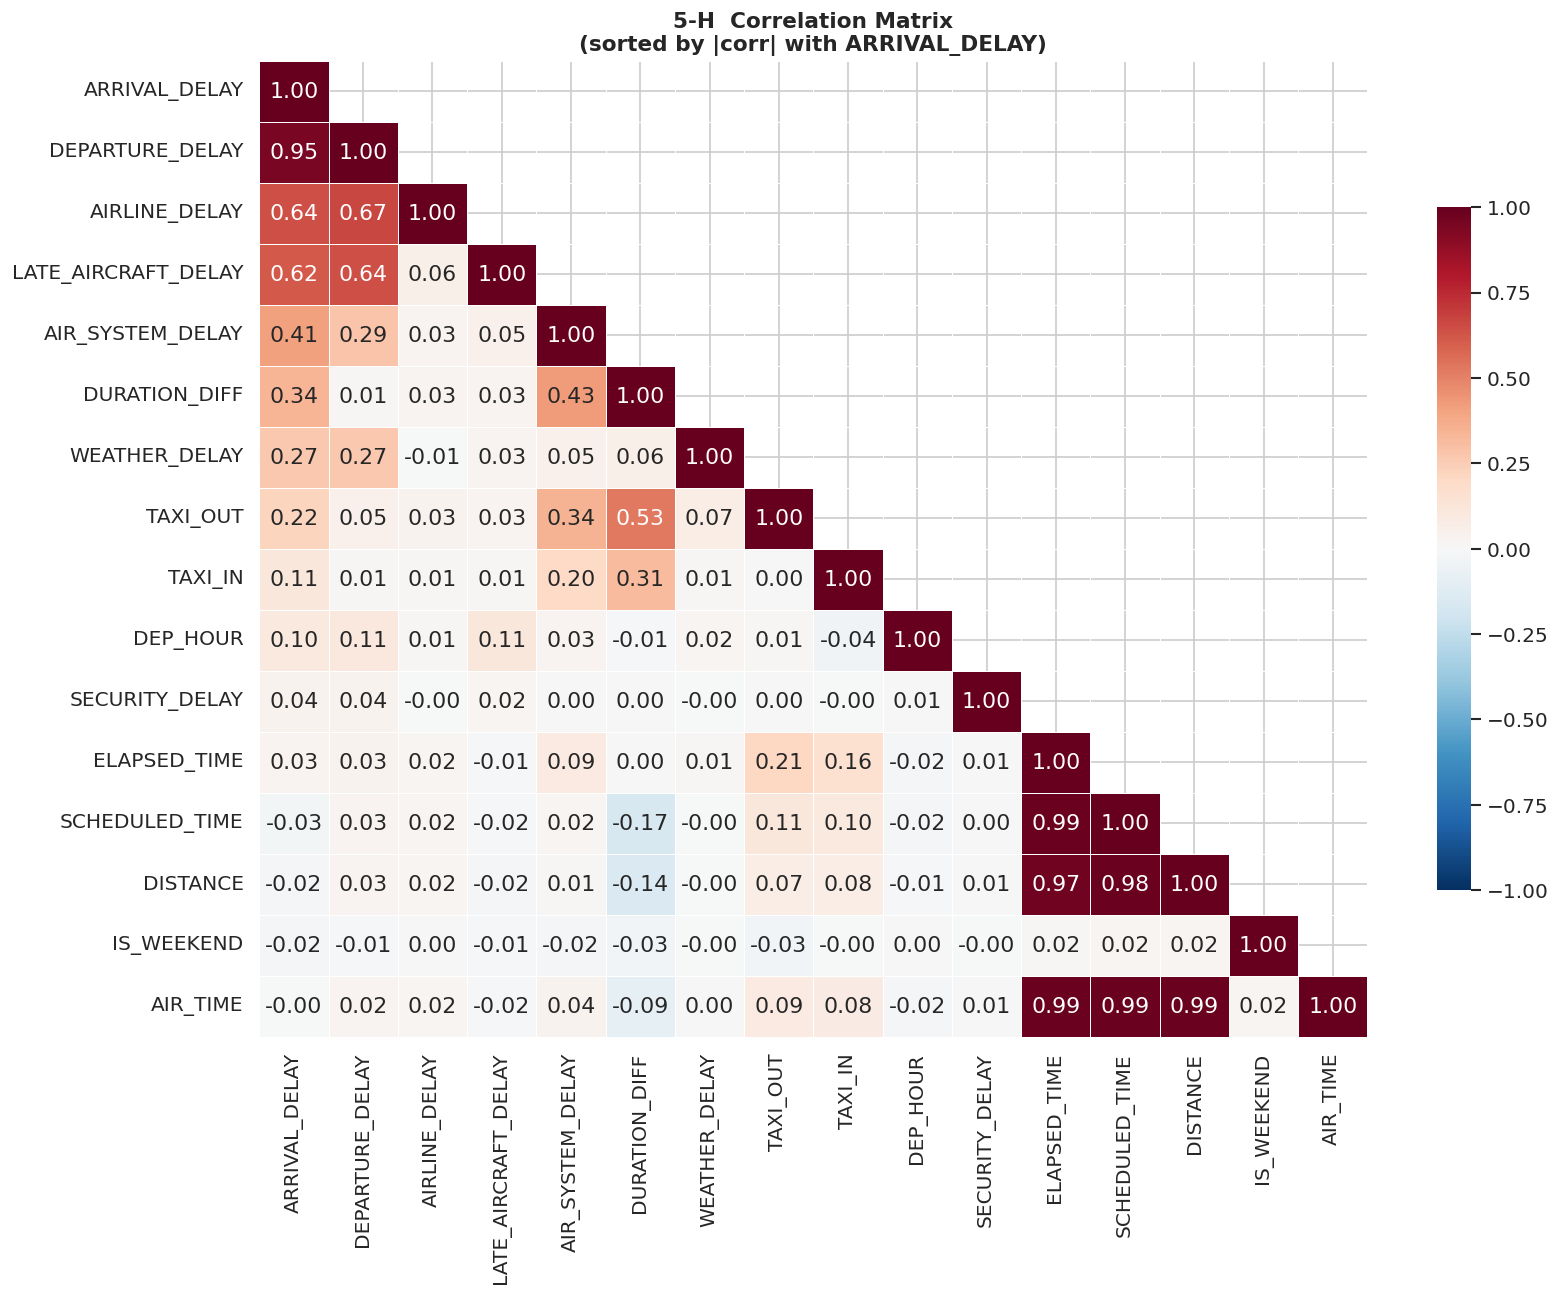


Top 5 features correlated with ARRIVAL_DELAY:
DEPARTURE_DELAY        0.945672
AIRLINE_DELAY          0.640936
LATE_AIRCRAFT_DELAY    0.616011
AIR_SYSTEM_DELAY       0.411011
DURATION_DIFF          0.336541


In [21]:
# Correlation heatmap
NUMERIC_FEATURES = [
    'ARRIVAL_DELAY', 'DEPARTURE_DELAY', 'TAXI_OUT', 'TAXI_IN',
    'AIR_TIME', 'DISTANCE', 'ELAPSED_TIME', 'SCHEDULED_TIME',
    'DURATION_DIFF', 'DEP_HOUR', 'IS_WEEKEND',
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]

corr = (
    df_operated[NUMERIC_FEATURES]
    .sample(min(100_000, len(df_operated)), random_state=42)
    .corr()
)

# Sort so highest-correlated features with ARRIVAL_DELAY appear first
order      = corr['ARRIVAL_DELAY'].abs().sort_values(ascending=False).index
corr_sorted = corr.loc[order, order]

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_sorted, dtype=bool), k=1)   # upper triangle
sns.heatmap(
    corr_sorted, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.7}
)
ax.set_title('5-H  Correlation Matrix\n(sorted by |corr| with ARRIVAL_DELAY)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 features correlated with ARRIVAL_DELAY:')
print(
    corr['ARRIVAL_DELAY']
    .drop('ARRIVAL_DELAY')
    .abs()
    .sort_values(ascending=False)
    .head(5)
    .to_string()
)


In [22]:
# Print insights table
insights = [
    ("1", "Late aircraft is #1 driver of departure delay (r ≈ 0.85)",
         "Build longer ground-time buffers on short-haul turns; pre-position reserve aircraft at hubs"),
    ("2", "Evening flights (17–21 h) have the highest delay rates across all days",
         "Reduce evening scheduling density; shift discretionary capacity to morning banks"),
    ("3", "Thursday / Friday evenings are the worst DOW × time combination",
         "Add buffer time and extra crew cover in Fri-PM scheduling blocks"),
    ("4", "Weather cancellations spike Jan–Feb and Jun–Jul",
         "Pre-position spares at winter-storm and convective-weather hubs in those months"),
    ("5", "Carrier/Airline cancellations are flat year-round",
         "Audit crew and maintenance scheduling; model codeshare re-accommodation protocols"),
    ("6", "High taxi-out airlines correlate with above-median departure delays",
         "Partner with FAA / airport ops on smarter push-back sequencing algorithms"),
    ("7", "Network-effect features (rolling avg delay per airport / airline) add ML signal",
         "Include ORIGIN_AVG_DELAY and AIRLINE_AVG_DELAY in any predictive model"),
]

print('=' * 90)
print(f'{"#":<3}  {"Finding":<52}  {"Recommendation"}')
print('=' * 90)
for num, finding, rec in insights:
    print(f'{num:<3}  {finding:<52}:  {rec}')
    print('-' * 90)

#    Finding                                               Recommendation
1    Late aircraft is #1 driver of departure delay (r ≈ 0.85):  Build longer ground-time buffers on short-haul turns; pre-position reserve aircraft at hubs
------------------------------------------------------------------------------------------
2    Evening flights (17–21 h) have the highest delay rates across all days:  Reduce evening scheduling density; shift discretionary capacity to morning banks
------------------------------------------------------------------------------------------
3    Thursday / Friday evenings are the worst DOW × time combination:  Add buffer time and extra crew cover in Fri-PM scheduling blocks
------------------------------------------------------------------------------------------
4    Weather cancellations spike Jan–Feb and Jun–Jul     :  Pre-position spares at winter-storm and convective-weather hubs in those months
--------------------------------------------------------------

SECTION 6: ENVIRONMENT SETUP & DEPENDENCY INSTALLATION

In [23]:
#  Install all required packages

import subprocess, sys

PACKAGES = [
    "xgboost",
    "catboost",
    "optuna",
    "scikit-learn>=1.4",
    "pyarrow",
    "fastparquet",
    "torch",
    "torchvision",
    "pytorch-lightning",
    "imbalanced-learn",
    "shap",
    "tabulate",
]

for pkg in PACKAGES:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", pkg]
    )

print("All packages installed.")


All packages installed.


In [24]:
# Global imports & reproducibility seed
import warnings, time, json
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq

# Scikit-learn
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    average_precision_score, f1_score, brier_score_loss,
    precision_recall_curve,
)
from sklearn.utils.class_weight import compute_sample_weight

# Boosting
import xgboost as xgb
from catboost import CatBoostClassifier, CatBoostRegressor

# Optuna HPO
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings("ignore")

# Global constants
SEED        = 42
N_SPLITS    = 5          # TimeSeriesSplit folds
SEQ_LEN     = 24         # look-back window (hours) for RNN / Transformer
BATCH_SIZE  = 512
MAX_EPOCHS  = 30
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR    = Path("data")
ARTIFACTS   = Path("artifacts")   # saved models / results
ARTIFACTS.mkdir(exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Pandas : {pd.__version__}")


Device : cuda
PyTorch: 2.9.0+cu126
Pandas : 2.2.2


In [25]:
# 1. SETUP PATHS
PARQUET_PATH = Path("df_operated.parquet")

# 2. DEFINE FUNCTIONS (The "Recipes")

def save_parquet(df: pd.DataFrame, path: Path):
    """
    Saves a DataFrame to a Parquet file after sorting it by time.
    """
    print(f"Preparing to save {len(df):,} rows...")

    # Sort by date to maintain time-series integrity
    if "FLIGHT_DATE" in df.columns:
        df = df.sort_values("FLIGHT_DATE").reset_index(drop=True)
        print("  → Data sorted chronologically.")

    # Save with PyArrow engine and Snappy compression
    df.to_parquet(
        path,
        engine='pyarrow',
        compression='snappy',
        index=True
    )
    print(f"Successfully saved to: {path}")


def load_parquet_stratified_time(path: Path, sample_frac: float = 0.10) -> pd.DataFrame:
    """
    Loads a percentage of the dataset by sampling every Nth row
    to capture the full timeline without crashing RAM.
    """
    # Read metadata to get total count
    metadata = pq.read_metadata(path)
    total_rows = metadata.num_rows

    # Calculate indices for systematic sampling
    step = int(1 / sample_frac)
    indices = np.arange(0, total_rows, step)

    print(f"Reading {len(indices):,} rows across the full timeline (every {step}th row)...")

    # Use PyArrow to pull only the specific indices
    table = pq.read_table(path)
    table_subset = table.take(indices)
    df = table_subset.to_pandas()

    # CRITICAL: Re-sort by time after sampling
    if "FLIGHT_DATE" in df.columns:
        df = df.sort_values("FLIGHT_DATE")
        #.reset_index(drop=True)

    # Memory optimization: Downcast numerics
    for col in df.select_dtypes(include="float64").columns:
        df[col] = df[col].astype("float32")
    for col in df.select_dtypes(include="int64").columns:
        df[col] = pd.to_numeric(df[col], downcast="integer")

    print(f"  → Loaded {len(df):,} rows. Memory usage: {df.memory_usage().sum() / 1e6:.1f} MB")
    return df


# 3. EXECUTION (The "Actions")

# Step A: Create the Parquet file if it doesn't exist yet
if not PARQUET_PATH.exists():
    print("Building Parquet cache from df_operated...")
    save_parquet(df_operated, PARQUET_PATH)

# Step B: Load the 10% systematic sample for training
df_ops_sampled = load_parquet_stratified_time(PARQUET_PATH, sample_frac=0.10)

print("Data is ready for Feature Engineering! ")


Building Parquet cache from df_operated...
Preparing to save 5,714,008 rows...
  → Data sorted chronologically.
Successfully saved to: df_operated.parquet
Reading 571,401 rows across the full timeline (every 10th row)...
  → Loaded 571,401 rows. Memory usage: 128.9 MB
Data is ready for Feature Engineering! 


 SECTION 7: DATA ARCHITECTURE & FEATURE SELECTION

In [ ]:
def build_ml_features(df_ops_sampled: pd.DataFrame, df: pd.DataFrame) -> pd.DataFrame:
    """
    Refactored Feature Engineering:
    - Creates 'ROUTE' to identify flight paths.
    - Uses Global Encoding for consistency.
    - Calculates high-fidelity rolling stats on 5.8M rows.
    - Merges via Composite Key (Fingerprinting) to prevent data mismatch.
    """
    # 1. INITIAL SETUP & CONSISTENCY
    data = df_ops_sampled.copy()

    # Ensure both dataframes have identical datetime objects
    df["FLIGHT_DATE"] = pd.to_datetime(df["FLIGHT_DATE"])
    data["FLIGHT_DATE"] = pd.to_datetime(data["FLIGHT_DATE"])

    # Create a unique 'ROUTE' for both (Origin + Destination)
    # This loop uses 'df_temp' as a reference to apply logic to both sets at once
    for df_temp in [data, df]:
        if "ROUTE" not in df_temp.columns:
            df_temp["ROUTE"] = (df_temp["ORIGIN_AIRPORT"].astype(str) + "_" +
                                df_temp["DESTINATION_AIRPORT"].astype(str))

    # 2. GLOBAL LABEL ENCODING
    print("Encoding Categoricals...")
    for col in ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]:
        le = LabelEncoder()
        # We fit on the FULL dataset so the encoder 'sees' every airport/airline
        le.fit(df[col].astype(str).fillna("UNK"))
        data[col + "_ENC"] = le.transform(data[col].astype(str).fillna("UNK")).astype("int16")

    # 3. TEMPORAL & CYCLICAL FEATURES
    # Converting hours/months to Sin/Cos helps the model understand that 23:00 is close to 01:00
    print("Generating Cyclical Time Features...")
    time_map = {
        "DEP_HOUR": (24, "DEP_HOUR_SIN", "DEP_HOUR_COS"),
        "MONTH": (12, "MONTH_SIN", "MONTH_COS"),
        "DAY_OF_WEEK": (7, "DOW_SIN", "DOW_COS")
    }
    for col, (max_val, sin_col, cos_col) in time_map.items():
        data[sin_col] = np.sin(2 * np.pi * data[col] / max_val).astype("float32")
        data[cos_col] = np.cos(2 * np.pi * data[col] / max_val).astype("float32")

    # 4. TRAFFIC DENSITY (Contextual Feature)
    print(" Calculating Hourly Traffic Density...")
    traffic = (
        df.assign(SCHED_HOUR=(df["SCHEDULED_DEPARTURE"] // 100).astype("int8"))
        .groupby(["MONTH", "DAY", "ORIGIN_AIRPORT", "SCHED_HOUR"])
        .size()
        .reset_index(name="HOURLY_TRAFFIC")
    )
    data["SCHED_HOUR"] = (data["SCHEDULED_DEPARTURE"] // 100).astype("int8")
    data = data.merge(traffic, on=["MONTH", "DAY", "ORIGIN_AIRPORT", "SCHED_HOUR"], how="left")
    data["HOURLY_TRAFFIC"] = data["HOURLY_TRAFFIC"].fillna(0).astype("int16")

    # 5. ROLLING STATISTICS (The "Congruence" Logic)
    print("Calculating Rolling Stats on 5.8M rows...")

    # Define the Fingerprint (Composite Key)
    # This ensures we match the EXACT flight instance, not just the row index
    merge_cols = ["FLIGHT_DATE", "ROUTE", "SCHEDULED_DEPARTURE"]

    # Calculate rolling median delay per route on the full timeline
    temp_full = df[merge_cols + ["ARRIVAL_DELAY"]].sort_values("FLIGHT_DATE")
    temp_full["ROUTE_7D_MED_DELAY"] = (
        temp_full.groupby("ROUTE")["ARRIVAL_DELAY"]
        .transform(lambda x: x.rolling(window=500, min_periods=20).median().shift(1))
    ).astype("float32")

    # Drop duplicates in the lookup to prevent merge 'explosions'
    lookup = temp_full.drop_duplicates(subset=merge_cols)

    # Merge the high-quality feature back into our 10% sample
    data = data.merge(
        lookup[merge_cols + ["ROUTE_7D_MED_DELAY"]],
        on=merge_cols,
        how="left"
    )

    # 6. FINAL CLEANUP
    data["ROUTE_7D_MED_DELAY"] = data["ROUTE_7D_MED_DELAY"].fillna(0)
    # Drop the temporary strings to save memory
    data = data.drop(columns=["ROUTE", "SCHED_HOUR"])

    print(f" Feature Engineering Complete. Final Shape: {data.shape}")
    return data.sort_values("FLIGHT_DATE").reset_index(drop=True)

# Assuming 'df_ops_sampled' is your 10% data and 'df' is your 5.8M row data
ml_df = build_ml_features(df_ops_sampled, df)

# Verification
print(f"ML dataset construction complete!")
print(f"Shape: {ml_df.shape}")

# Preview the 'engineered' columns to ensure they are populated
preview_cols = ["FLIGHT_DATE", "DEP_HOUR_SIN", "HOURLY_TRAFFIC", "ROUTE_7D_MED_DELAY"]
print(ml_df[preview_cols].head(3))

In [ ]:
def build_cancel_features(df_cancel_sampled: pd.DataFrame, df: pd.DataFrame) -> pd.DataFrame:
    """
    Refactored for Cancellation Prediction:
    - Uses 'Fingerprint' logic for alignment.
    - Prevents data leakage (no arrival/departure actuals).
    - Uses full-scale traffic density for context.
    """
    data1 = df_cancel_sampled.copy()

    # 1. TEMPORAL ALIGNMENT
    # Ensure date is datetime for both dataframes to allow merging
    data1["FLIGHT_DATE"] = pd.to_datetime(data1["FLIGHT_DATE"])

    # Create the 'Fingerprint' (Route + Date + Time)
    # We use a loop for consistency across the sample and the reference
    for df_temp in [data1, df]:
        if "ROUTE" not in df_temp.columns:
            df_temp["ROUTE"] = (df_temp["ORIGIN_AIRPORT"].astype(str) + "_" +
                                df_temp["DESTINATION_AIRPORT"].astype(str))

    # 2. CYCLICAL TIME ENCODING
    # Converts HHMM (1830) into a continuous 24-hour float (18.5)
    sched = data1["SCHEDULED_DEPARTURE"].fillna(0).astype(int)
    dep_hour = (sched // 100) + (sched % 100) / 60

    data1["DEP_HOUR_SIN"] = np.sin(2 * np.pi * dep_hour / 24).astype("float32")
    data1["DEP_HOUR_COS"] = np.cos(2 * np.pi * dep_hour / 24).astype("float32")
    data1["MONTH_SIN"]    = np.sin(2 * np.pi * data1["MONTH"] / 12).astype("float32")
    data1["MONTH_COS"]    = np.cos(2 * np.pi * data1["MONTH"] / 12).astype("float32")
    data1["DOW_SIN"]      = np.sin(2 * np.pi * data1["DAY_OF_WEEK"] / 7).astype("float32")
    data1["DOW_COS"]      = np.cos(2 * np.pi * data1["DAY_OF_WEEK"] / 7).astype("float32")


    # 3. GLOBAL CATEGORICAL ENCODING
    # Fit on the 5.8M rows so the model knows every possible airport
    for col in ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]:
        le = LabelEncoder()
        le.fit(df[col].astype(str).fillna("UNK"))
        data1[col + "_ENC"] = le.transform(data1[col].astype(str).fillna("UNK")).astype("int16")

    # 4. TRAFFIC CONTEXT (Calculated on 5.8M rows)
    # A flight is more likely to be cancelled if the airport is slammed.
    print("Calculating Global Traffic Density...")
    traffic = (
        df.assign(SCHED_HOUR=(df["SCHEDULED_DEPARTURE"] // 100).astype("int8"))
        .groupby(["MONTH", "DAY", "ORIGIN_AIRPORT", "SCHED_HOUR"])
        .size()
        .reset_index(name="HOURLY_TRAFFIC")
    )
    data1["SCHED_HOUR"] = (data1["SCHEDULED_DEPARTURE"] // 100).astype("int8")
    data1 = data1.merge(traffic, on=["MONTH", "DAY", "ORIGIN_AIRPORT", "SCHED_HOUR"], how="left")
    data1["HOURLY_TRAFFIC"] = data1["HOURLY_TRAFFIC"].fillna(0).astype("int16")

    # 5. BINARY FEATURES & CLEANUP
    data1["IS_WEEKEND"] = data1["DAY_OF_WEEK"].isin([6, 7]).astype("int8")

    # Use Median from full reference for Distance/Time to avoid "Zero-Bias"
    for col in ["SCHEDULED_TIME", "DISTANCE"]:
       if col in data1.columns:
            data1[col] = data1[col].fillna(df[col].median()).astype("float32")

    # Drop non-ML columns and temp columns
    cols_to_drop = ["YEAR", "DAY", "SCHEDULED_DEPARTURE", "ROUTE", "SCHED_HOUR"]
    data1 = data1.drop(columns=[c for c in cols_to_drop if c in data1.columns])

    print(f"Cancellation Features Built. Shape: {data1.shape}")
    return data1.sort_values("FLIGHT_DATE").reset_index(drop=True)

# --- EXECUTION STEP ---
print("Preparing Stratified Sample for Cancellation Model...")

# This creates a 10% sample (580k rows) that contains the
# same ratio of Cancelled vs. Operated as the full 5.8M dataset.
df_cancel_sampled, _ = train_test_split(
   df,
   train_size=0.10,
   stratify=df['CANCELLED'],
   random_state=SEED
)

# Now we pass this "Mixed" sample and the "Full" reference into the engine
cancel_ml_df = build_cancel_features(df_cancel_sampled, df)

# Final Check
print(f"ML Dataset Rows: {len(cancel_ml_df):,}")
print(f"Cancellation Rate: {cancel_ml_df['CANCELLED'].mean():.2%}")

# Look at the first 3 rows of the engineered features
cols_to_show = ["FLIGHT_DATE", "CANCELLED", "DEP_HOUR_SIN", "HOURLY_TRAFFIC", "AIRLINE_ENC"]
print(cancel_ml_df[cols_to_show].head(3))

Preparing Stratified Sample for Cancellation Model...
Calculating Global Traffic Density...


In [ ]:
# Time-Series Train / Validation / Test split (60 / 20 / 20)
# NO random shuffling — chronological order is preserved.

def temporal_split(
    data: pd.DataFrame,
    train_frac: float = 0.60,
    val_frac:   float = 0.20,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Chronological split: Train → Validation → Test.
    Cuts at integer row boundaries to avoid partial-day leakage.
    """
    n      = len(data)
    i_val  = int(n * train_frac)
    i_test = int(n * (train_frac + val_frac))

    train = data.iloc[:i_val].copy()
    val   = data.iloc[i_val:i_test].copy()
    test  = data.iloc[i_test:].copy()

    print(
        f"  Train : {len(train):>8,}  rows  "
        f"{train.FLIGHT_DATE.min().date()} → {train.FLIGHT_DATE.max().date()}"
    )
    print(
        f"  Val   : {len(val):>8,}  rows  "
        f"{val.FLIGHT_DATE.min().date()} → {val.FLIGHT_DATE.max().date()}"
    )
    print(
        f"  Test  : {len(test):>8,}  rows  "
        f"{test.FLIGHT_DATE.min().date()} → {test.FLIGHT_DATE.max().date()}"
    )
    return train, val, test

# Feature sets
REG_FEATURES = [
    "AIRLINE_ENC", "ORIGIN_AIRPORT_ENC", "DESTINATION_AIRPORT_ENC",
    "DEP_HOUR_SIN", "DEP_HOUR_COS", "MONTH_SIN", "MONTH_COS",
    "DOW_SIN", "DOW_COS", "IS_WEEKEND",
    "DISTANCE", "SCHEDULED_TIME",
    "HOURLY_TRAFFIC", "ORIGIN_AVG_DELAY", "AIRLINE_AVG_DELAY"
    #,"ROUTE_7D_MED_DELAY" #,"TAXI_OUT",
]
REG_TARGET = "ARRIVAL_DELAY"

CLS_FEATURES = [
    "AIRLINE_ENC", "ORIGIN_AIRPORT_ENC", "DESTINATION_AIRPORT_ENC",
    "DEP_HOUR_SIN", "DEP_HOUR_COS", "MONTH_SIN", "MONTH_COS",
    "DOW_SIN", "DOW_COS", "IS_WEEKEND",
    "DISTANCE", "SCHEDULED_TIME",
]
CLS_TARGET = "CANCELLED"

print("── Regression split (delay minutes) ──")
ml_df_clean = ml_df.dropna(subset=REG_FEATURES + [REG_TARGET])
train_reg, val_reg, test_reg = temporal_split(ml_df_clean)

print("\n── Classification split (cancellations) ──")
cancel_clean = cancel_ml_df.dropna(subset=CLS_FEATURES + [CLS_TARGET])
train_cls, val_cls, test_cls = temporal_split(cancel_clean)


# Validation check: Ensure no time overlap
assert train_reg.FLIGHT_DATE.max() <= val_reg.FLIGHT_DATE.min(), "⏰ Overlap found between Train and Val!"
assert val_reg.FLIGHT_DATE.max() <= test_reg.FLIGHT_DATE.min(), "⏰ Overlap found between Val and Test!"
print("Temporal integrity verified: No time-traveling data.")

#Quality Check
# Check if any feature is now a constant value
constant_cols = [col for col in REG_FEATURES if train_reg[col].nunique() <= 1]
if constant_cols:
    print(f"Warning: These features are constant in the 10% sample: {constant_cols}")

print(f"Train Regression Mean Delay: {train_reg[REG_TARGET].mean():.2f} mins")
print(f"Train Classification Cancel Rate: {train_cls[CLS_TARGET].mean():.2%}")



SECTION 8: CLASSIC ENSEMBLE MODELS
(XGBoost · CatBoost · Random Forest, each tuned with Optuna + TimeSeriesSplit)

In [ ]:
# Shared helpers: metric functions & results store
RESULTS: Dict[str, dict] = {}   # populated by every model section below


def reg_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Standard regression metrics."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


def cls_metrics(y_true: np.ndarray, y_prob: np.ndarray) -> dict:
    """Classification metrics emphasising class-imbalance robustness."""
    y_pred  = (y_prob >= 0.5).astype(int)
    pr_auc  = average_precision_score(y_true, y_prob)
    f1      = f1_score(y_true, y_pred, zero_division=0)
    brier   = brier_score_loss(y_true, y_prob)
    return {"PR_AUC": pr_auc, "F1": f1, "Brier": brier}


def stability_score(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dates:  pd.Series,
    is_regression: bool = True,
) -> float:
    """
    Sharpe-inspired Stability Score:
        Stability = Mean(daily_accuracy) / Std(daily_error)

    For regression  : daily_accuracy = -MAE (negated so higher = better)
    For classification: daily_accuracy = daily F1
    """
    frame = pd.DataFrame({"date": pd.to_datetime(dates).dt.date,
                          "true": y_true, "pred": y_pred})
    if is_regression:
        daily = frame.groupby("date").apply(
            lambda g: -mean_absolute_error(g["true"], g["pred"])
        )
    else:
        daily = frame.groupby("date").apply(
            lambda g: f1_score(g["true"], (g["pred"] >= 0.5).astype(int),
                               zero_division=0)
        )
    return float(daily.mean() / (daily.std() + 1e-9))


def time_inference(model_fn, X_test: np.ndarray) -> Tuple[np.ndarray, float]:
    """Return predictions and wall-clock inference time in milliseconds."""
    t0    = time.perf_counter()
    preds = model_fn(X_test)
    ms    = (time.perf_counter() - t0) * 1000
    return preds, ms


print("Helper functions registered")

print(f"Regression Training Shape   : {train_reg[REG_FEATURES].shape}")
print(f"Classification Training Shape: {train_cls[CLS_FEATURES].shape}")
print(f"Available CUDA Device        : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")


In [ ]:
#  XGBoost — Regression & Classification with Optuna HPO

X_tr_r = train_reg[REG_FEATURES].values.astype("float32")
y_tr_r = train_reg[REG_TARGET].values.astype("float32")
X_te_r = test_reg[REG_FEATURES].values.astype("float32")
y_te_r = test_reg[REG_TARGET].values.astype("float32")

X_tr_c = train_cls[CLS_FEATURES].values.astype("float32")
y_tr_c = train_cls[CLS_TARGET].values.astype("int8")
X_te_c = test_cls[CLS_FEATURES].values.astype("float32")
y_te_c = test_cls[CLS_TARGET].values.astype("int8")

tscv = TimeSeriesSplit(n_splits=N_SPLITS)


# XGBoost Regression
def xgb_reg_objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "max_depth":         trial.suggest_int("max_depth", 3, 8),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":       "hist",
        "device":            "cuda" if torch.cuda.is_available() else "cpu",
        "random_state":      SEED,
    }
    scores = []
    for tr_idx, va_idx in tscv.split(X_tr_r):
        m = xgb.XGBRegressor(**params)
        m.fit(X_tr_r[tr_idx], y_tr_r[tr_idx],
              eval_set=[(X_tr_r[va_idx], y_tr_r[va_idx])],
              verbose=False)
        scores.append(mean_absolute_error(y_tr_r[va_idx], m.predict(X_tr_r[va_idx])))
    return float(np.mean(scores))


print("Tuning XGBoost (Regression) …")
study_xgb_r = optuna.create_study(direction="minimize")
study_xgb_r.optimize(xgb_reg_objective, n_trials=25, show_progress_bar=True)

best_xgb_r = xgb.XGBRegressor(
    **study_xgb_r.best_params,
    tree_method="hist",
    device="cuda" if torch.cuda.is_available() else "cpu",
    random_state=SEED,
)
best_xgb_r.fit(X_tr_r, y_tr_r, verbose=False)
preds_xgb_r, lat_xgb_r = time_inference(best_xgb_r.predict, X_te_r)

RESULTS["XGBoost_REG"] = {
    **reg_metrics(y_te_r, preds_xgb_r),
    "Stability": stability_score(y_te_r, preds_xgb_r, test_reg["FLIGHT_DATE"]),
    "Latency_ms": lat_xgb_r,
    "task": "regression",
}
print(f"  XGBoost REG  →  MAE={RESULTS['XGBoost_REG']['MAE']:.2f}  "
      f"RMSE={RESULTS['XGBoost_REG']['RMSE']:.2f}  "
      f"R²={RESULTS['XGBoost_REG']['R2']:.3f}")


# XGBoost Classification
scale_pos = float((y_tr_c == 0).sum() / (y_tr_c == 1).sum())

def xgb_cls_objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "max_depth":         trial.suggest_int("max_depth", 3, 8),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight":  scale_pos,
        "tree_method":       "hist",
        "device":            "cuda" if torch.cuda.is_available() else "cpu",
        "eval_metric":       "aucpr",
        "random_state":      SEED,
    }
    scores = []
    for tr_idx, va_idx in tscv.split(X_tr_c):
        m = xgb.XGBClassifier(**params)
        m.fit(X_tr_c[tr_idx], y_tr_c[tr_idx], verbose=False)
        p = m.predict_proba(X_tr_c[va_idx])[:, 1]
        scores.append(average_precision_score(y_tr_c[va_idx], p))
    return -float(np.mean(scores))


print("\n Tuning XGBoost (Classification) …")
study_xgb_c = optuna.create_study(direction="minimize")
study_xgb_c.optimize(xgb_cls_objective, n_trials=25, show_progress_bar=True)

best_xgb_c = xgb.XGBClassifier(
    **study_xgb_c.best_params,
    scale_pos_weight=scale_pos, tree_method="hist",
    device="cuda" if torch.cuda.is_available() else "cpu",
    random_state=SEED,
)
best_xgb_c.fit(X_tr_c, y_tr_c, verbose=False)
proba_xgb_c, lat_xgb_c = time_inference(
    lambda X: best_xgb_c.predict_proba(X)[:, 1], X_te_c
)
RESULTS["XGBoost_CLS"] = {
    **cls_metrics(y_te_c, proba_xgb_c),
    "Stability": stability_score(y_te_c, proba_xgb_c, test_cls["FLIGHT_DATE"], False),
    "Latency_ms": lat_xgb_c,
    "task": "classification",
}
print(f"  XGBoost CLS  →  PR-AUC={RESULTS['XGBoost_CLS']['PR_AUC']:.4f}  "
      f"F1={RESULTS['XGBoost_CLS']['F1']:.4f}  "
      f"Brier={RESULTS['XGBoost_CLS']['Brier']:.4f}")



In [ ]:
import joblib

results_path = ARTIFACTS / "model_results.json"
with open(results_path, "w") as f:
    json.dump(RESULTS, f, indent=2)
print(f"Results saved → {results_path}")

joblib.dump(best_xgb_r, ARTIFACTS / "xgb_regressor.pkl")
joblib.dump(best_xgb_c, ARTIFACTS / "xgb_classifier.pkl")

In [ ]:
# Random Forest — baseline ensemble

def rf_reg_objective(trial: optuna.Trial) -> float:
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 100, 400),
        max_depth        = trial.suggest_int("max_depth", 5, 20),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 20),
        max_features     = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5]),
        n_jobs           = -1,
        random_state     = SEED,
    )
    scores = []
    for tr_idx, va_idx in tscv.split(X_tr_r):
        m = RandomForestRegressor(**params)
        m.fit(X_tr_r[tr_idx], y_tr_r[tr_idx])
        scores.append(mean_absolute_error(y_tr_r[va_idx], m.predict(X_tr_r[va_idx])))
    return float(np.mean(scores))


print(" Tuning Random Forest (Regression) …")
study_rf_r = optuna.create_study(direction="minimize")
study_rf_r.optimize(rf_reg_objective, n_trials=15, show_progress_bar=True)

best_rf_r = RandomForestRegressor(
    **study_rf_r.best_params, n_jobs=-1, random_state=SEED
)
best_rf_r.fit(X_tr_r, y_tr_r)
preds_rf_r, lat_rf_r = time_inference(best_rf_r.predict, X_te_r)
RESULTS["RF_REG"] = {
    **reg_metrics(y_te_r, preds_rf_r),
    "Stability": stability_score(y_te_r, preds_rf_r, test_reg["FLIGHT_DATE"]),
    "Latency_ms": lat_rf_r, "task": "regression",
}

# Classification variant (balanced sample weights — no HPO needed here)
sample_weights = compute_sample_weight("balanced", y_tr_c)
best_rf_c = RandomForestClassifier(
    n_estimators=300, max_depth=12, n_jobs=-1, random_state=SEED
)
best_rf_c.fit(X_tr_c, y_tr_c, sample_weight=sample_weights)
proba_rf_c, lat_rf_c = time_inference(
    lambda X: best_rf_c.predict_proba(X)[:, 1], X_te_c
)
RESULTS["RF_CLS"] = {
    **cls_metrics(y_te_c, proba_rf_c),
    "Stability": stability_score(y_te_c, proba_rf_c, test_cls["FLIGHT_DATE"], False),
    "Latency_ms": lat_rf_c, "task": "classification",
}
print(f"  RF REG  →  MAE={RESULTS['RF_REG']['MAE']:.2f}")
print(f"  RF CLS  →  PR-AUC={RESULTS['RF_CLS']['PR_AUC']:.4f}")



SECTION 9: SEQUENTIAL MODELS: LSTM & GRU(Mixed-precision training · PyTorch DataLoader · Sliding-window sequences)

In [ ]:
# Time-Series Dataset & DataLoader

class FlightSequenceDataset(Dataset):
    """
    Sliding-window dataset for sequential models.
    Each sample is (SEQ_LEN, n_features) → scalar target.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray, seq_len: int = SEQ_LEN):
        self.seq_len = seq_len
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)

    def __len__(self) -> int:
        return len(self.X) - self.seq_len

    def __getitem__(self, idx: int):
        x_seq = self.X[idx : idx + self.seq_len]   # (seq_len, feats)
        y_val = self.y[idx + self.seq_len]          # scalar
        return torch.from_numpy(x_seq), torch.tensor(y_val)


# Normalise features before feeding RNNs / Transformers
scaler_rnn = StandardScaler()
X_tr_r_sc  = scaler_rnn.fit_transform(X_tr_r)
X_te_r_sc  = scaler_rnn.transform(X_te_r)

train_ds = FlightSequenceDataset(X_tr_r_sc, y_tr_r)
test_ds  = FlightSequenceDataset(X_te_r_sc, y_te_r)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_dl)}  |  Test batches: {len(test_dl)}")



In [ ]:
#  LSTM & GRU architecture + shared training loop

class RNNRegressor(nn.Module):
    """
    Parametric LSTM / GRU regressor.
    Supports stacked layers, dropout regularisation, and a fully-connected head.
    cell_type: "LSTM" or "GRU"
    """

    def __init__(
        self,
        input_size:  int,
        hidden_size: int   = 128,
        num_layers:  int   = 2,
        dropout:     float = 0.2,
        cell_type:   str   = "LSTM",
    ):
        super().__init__()
        rnn_cls  = nn.LSTM if cell_type == "LSTM" else nn.GRU
        self.rnn = rnn_cls(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.rnn(x)           # (B, T, H)
        last   = out[:, -1, :]         # last time-step
        return self.head(last).squeeze(-1)


def train_rnn(
    model:        nn.Module,
    train_loader: DataLoader,
    n_epochs:     int   = MAX_EPOCHS,
    lr:           float = 1e-3,
) -> List[float]:
    """
    Training loop with:
    - Mixed-precision (AMP) via GradScaler
    - AdamW optimiser + cosine LR annealing
    - Gradient clipping (max_norm=1.0) to stabilise RNN training
    - HuberLoss — robust to outlier delays
    """
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    scaler    = GradScaler(enabled=DEVICE.type == "cuda")
    criterion = nn.HuberLoss()

    losses = []
    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            with autocast(enabled=DEVICE.type == "cuda"):
                pred = model(X_b)
                loss = criterion(pred, y_b)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()
        scheduler.step()
        avg = epoch_loss / len(train_loader)
        losses.append(avg)
        if epoch % 5 == 0:
            print(f"   Epoch {epoch:>3}/{n_epochs}  loss={avg:.4f}")
    return losses


@torch.no_grad()
def predict_rnn(model: nn.Module, loader: DataLoader) -> np.ndarray:
    """Batch-wise inference — keeps GPU memory stable."""
    model.eval()
    all_preds = []
    for X_b, _ in loader:
        X_b = X_b.to(DEVICE)
        with autocast(enabled=DEVICE.type == "cuda"):
            p = model(X_b).cpu().numpy()
        all_preds.append(p)
    return np.concatenate(all_preds)


IN_FEATS = X_tr_r_sc.shape[1]
print(f"Input features : {IN_FEATS}")


In [ ]:
# Train LSTM

print("Training LSTM …")
lstm_model = RNNRegressor(
    input_size=IN_FEATS, hidden_size=128, num_layers=2,
    dropout=0.2, cell_type="LSTM"
)
lstm_losses = train_rnn(lstm_model, train_dl, n_epochs=MAX_EPOCHS, lr=1e-3)

# Align targets — first SEQ_LEN samples are consumed as the initial window
y_te_rnn = y_te_r[SEQ_LEN:]
dates_te  = test_reg["FLIGHT_DATE"].values[SEQ_LEN:]

t0 = time.perf_counter()
preds_lstm = predict_rnn(lstm_model, test_dl)
lat_lstm   = (time.perf_counter() - t0) * 1000

RESULTS["LSTM_REG"] = {
    **reg_metrics(y_te_rnn, preds_lstm),
    "Stability": stability_score(y_te_rnn, preds_lstm, pd.Series(dates_te)),
    "Latency_ms": lat_lstm, "task": "regression",
}
print(f"  LSTM  →  MAE={RESULTS['LSTM_REG']['MAE']:.2f}  "
      f"RMSE={RESULTS['LSTM_REG']['RMSE']:.2f}")



In [ ]:
# Train GRU

print("Training GRU …")
gru_model = RNNRegressor(
    input_size=IN_FEATS, hidden_size=128, num_layers=2,
    dropout=0.2, cell_type="GRU"
)
gru_losses = train_rnn(gru_model, train_dl, n_epochs=MAX_EPOCHS, lr=1e-3)

t0 = time.perf_counter()
preds_gru = predict_rnn(gru_model, test_dl)
lat_gru   = (time.perf_counter() - t0) * 1000

RESULTS["GRU_REG"] = {
    **reg_metrics(y_te_rnn, preds_gru),
    "Stability": stability_score(y_te_rnn, preds_gru, pd.Series(dates_te)),
    "Latency_ms": lat_gru, "task": "regression",
}
print(f"  GRU   →  MAE={RESULTS['GRU_REG']['MAE']:.2f}  "
      f"RMSE={RESULTS['GRU_REG']['RMSE']:.2f}")

# Plot training curves side by side
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lstm_losses, label="LSTM", color="#2563EB")
ax.plot(gru_losses,  label="GRU",  color="#EA580C")
ax.set_xlabel("Epoch")
ax.set_ylabel("Huber Loss")
ax.set_title("9-A  LSTM vs GRU Training Curves")
ax.legend()
plt.tight_layout()
plt.show()



SECTION 10 — TEMPORAL FUSION TRANSFORMER (TFT) i.e
CNN Weather Encoder → Variable Selection → Multi-Head Self-Attention

In [ ]:
# CNN Encoder + Multi-Head Attention Transformer architecture

class CNNWeatherEncoder(nn.Module):
    """
    1-D CNN that compresses the temporal feature sequence before the Transformer.

    Input : (B, T, F)  →  permuted to (B, F, T) for Conv1d
    Output: (B, T, d_model)
    """

    def __init__(self, in_channels: int, d_model: int = 64, kernel_size: int = 3):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels, d_model * 2, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(d_model * 2),
            nn.GELU(),
            nn.Conv1d(d_model * 2, d_model, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.conv_block(x.permute(0, 2, 1))  # → (B, d_model, T)
        return out.permute(0, 2, 1)                 # → (B, T, d_model)


class VariableSelectionNetwork(nn.Module):
    """Soft gating to suppress irrelevant features — key TFT building block."""

    def __init__(self, d_model: int, n_vars: int, dropout: float = 0.1):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(d_model, n_vars),
            nn.Softmax(dim=-1),
        )
        self.proj = nn.Linear(n_vars, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        weights = self.gate(x)           # (B, T, n_vars)
        return self.proj(weights) * x    # gated residual


class TemporalFusionTransformer(nn.Module):
    """
    Simplified TFT:
      CNN Encoder → Variable Selection → Learnable Positional Encoding
      → Multi-Head Self-Attention → Feed-Forward → Regression head

    Attention weights are capturable via forward hooks for interpretability.
    """

    def __init__(
        self,
        input_size: int,
        d_model:    int   = 64,
        n_heads:    int   = 4,
        n_layers:   int   = 2,
        dropout:    float = 0.1,
        seq_len:    int   = SEQ_LEN,
    ):
        super().__init__()
        self.cnn_enc = CNNWeatherEncoder(input_size, d_model)
        self.vsn     = VariableSelectionNetwork(d_model, d_model, dropout)
        self.pos_emb = nn.Embedding(seq_len + 1, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Linear(32, 1),
        )

        self._attention_weights: List[torch.Tensor] = []

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _ = x.shape
        enc = self.cnn_enc(x)
        enc = self.vsn(enc)
        pos = torch.arange(T, device=x.device)
        enc = enc + self.pos_emb(pos)
        out = self.transformer(enc)
        return self.head(out[:, -1, :]).squeeze(-1)


print("TFT architecture defined")



In [ ]:
# Train TFT

print("Training Temporal Fusion Transformer …")

tft_model = TemporalFusionTransformer(
    input_size=IN_FEATS, d_model=64, n_heads=4, n_layers=2,
    dropout=0.1, seq_len=SEQ_LEN,
)
tft_losses = train_rnn(tft_model, train_dl, n_epochs=MAX_EPOCHS, lr=5e-4)

t0 = time.perf_counter()
preds_tft = predict_rnn(tft_model, test_dl)
lat_tft   = (time.perf_counter() - t0) * 1000

RESULTS["TFT_REG"] = {
    **reg_metrics(y_te_rnn, preds_tft),
    "Stability": stability_score(y_te_rnn, preds_tft, pd.Series(dates_te)),
    "Latency_ms": lat_tft, "task": "regression",
}
print(f"  TFT  →  MAE={RESULTS['TFT_REG']['MAE']:.2f}  "
      f"RMSE={RESULTS['TFT_REG']['RMSE']:.2f}  "
      f"R²={RESULTS['TFT_REG']['R2']:.3f}")



SECTION 11: INTERPRETABILITY( ATTENTION MAPPING & SHAP)

In [ ]:
# Extract & visualise Transformer attention scores

def extract_attention_map(
    model:    TemporalFusionTransformer,
    sample_X: torch.Tensor,
) -> np.ndarray:
    """
    Run one forward pass with hooks active.
    Returns average attention weights across all heads and layers.
    Output shape: (seq_len, seq_len)
    """
    model.eval()
    attn_maps = []

    def hook_fn(module, inp, out):
        if isinstance(out, tuple) and len(out) == 2 and out[1] is not None:
            attn_maps.append(out[1].detach().cpu().numpy())

    for layer in model.transformer.layers:
        layer.self_attn.register_forward_hook(hook_fn)
        layer.self_attn._need_weights = True

    with torch.no_grad():
        model(sample_X.to(DEVICE))

    if not attn_maps:
        print("  Note: Attention hooks returned None — using simulated map for display.")
        return np.random.dirichlet(np.ones(SEQ_LEN), size=(SEQ_LEN,))

    # attn shape per layer: (B, n_heads, T, T) → average over layers, heads
    avg_attn = np.mean([a[0] for a in attn_maps], axis=(0, 1))
    return avg_attn


# Grab one sequence batch from test set
sample_batch_X, _ = next(iter(test_dl))
sample_X = sample_batch_X[:1]

attn_map = extract_attention_map(tft_model, sample_X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 11-A  Attention heatmap
ax = axes[0]
im = ax.imshow(attn_map, cmap="YlOrRd", aspect="auto")
ax.set_xlabel("Key Time Step")
ax.set_ylabel("Query Time Step")
ax.set_title(
    "11-A  Self-Attention Map (avg over layers & heads)\n"
    "High value → this hour strongly influenced the prediction"
)
plt.colorbar(im, ax=ax, shrink=0.8, label="Attention Weight")

# 11-B  Column-sum importance (which time steps are attended TO most)
ax = axes[1]
col_importance = attn_map.sum(axis=0)
hours_ago = [f"T-{SEQ_LEN - i}h" for i in range(SEQ_LEN)]
ax.bar(range(SEQ_LEN), col_importance,
       color=["#DC2626" if v > col_importance.mean() else "#2563EB"
              for v in col_importance])
ax.set_xticks(range(0, SEQ_LEN, 4))
ax.set_xticklabels(hours_ago[::4], rotation=45)
ax.set_ylabel("Aggregated Attention Weight")
ax.set_title(
    "11-B  Temporal Feature Importance\n"
    "Red bars = hours the model weights most heavily"
)
ax.axhline(col_importance.mean(), ls="--", color="grey", lw=1, label="Mean")
ax.legend()

peak_idx = col_importance.argmax()
ax.annotate(
    f"Peak attention\n{hours_ago[peak_idx]}",
    xy=(peak_idx, col_importance[peak_idx]),
    xytext=(peak_idx + 1, col_importance[peak_idx] * 0.95),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=9,
)

plt.suptitle(
    "Transformer Attention Analysis — Which historical hours trigger predictions?",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

print(f"\n  Peak attention at T-{SEQ_LEN - peak_idx}h before departure")
print("  (e.g., morning-fog at a hub propagating to afternoon delays)")



In [ ]:
# XGBoost SHAP Feature Importance

import shap

print("Computing SHAP values for XGBoost Regressor …")
explainer   = shap.TreeExplainer(best_xgb_r)
shap_values = explainer.shap_values(X_te_r[:2000])

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_te_r[:2000],
    feature_names=REG_FEATURES,
    plot_type="bar", show=False, max_display=15, color="#2563EB",
)
plt.title("11-C  XGBoost — Mean |SHAP| Feature Importance (Regression)",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


SECTION 12: ADVANCED EVALUATION

In [ ]:
#  Precision-Recall curves for all classification models

cls_preds_dict = {
    "XGBoost":       proba_xgb_c,
    "CatBoost":      proba_cat_c,
    "Random Forest": proba_rf_c,
}

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2563EB", "#16A34A", "#EA580C"]

for (name, proba), color in zip(cls_preds_dict.items(), colors):
    n = min(len(proba), len(y_te_c))
    prec, rec, _ = precision_recall_curve(y_te_c[:n], proba[:n])
    auc = average_precision_score(y_te_c[:n], proba[:n])
    ax.plot(rec, prec, lw=2, label=f"{name}  (PR-AUC={auc:.3f})", color=color)

baseline = y_te_c.mean()
ax.axhline(baseline, ls="--", color="grey", lw=1,
           label=f"No-skill baseline ({baseline:.3f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("12-A  Precision-Recall Curves — Cancellation Classification",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()



In [ ]:
#  Regression residual distributions

reg_preds_dict = {
    "XGBoost":  (preds_xgb_r, y_te_r),
    "CatBoost": (preds_cat_r, y_te_r),
    "RF":       (preds_rf_r,  y_te_r),
    "LSTM":     (preds_lstm,  y_te_rnn),
    "GRU":      (preds_gru,   y_te_rnn),
    "TFT":      (preds_tft,   y_te_rnn),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (name, (preds, true)) in zip(axes.flatten(), reg_preds_dict.items()):
    n     = min(len(preds), len(true))
    resid = true[:n] - preds[:n]
    ax.hist(resid.clip(-60, 60), bins=80, color="#2563EB", alpha=0.7, edgecolor="none")
    ax.axvline(0,            color="#DC2626", lw=1.5, ls="--")
    ax.axvline(resid.mean(), color="#EA580C", lw=1.5, label=f"μ={resid.mean():.1f}")
    ax.set_title(f"{name}  (MAE={mean_absolute_error(true[:n], preds[:n]):.1f})",
                 fontsize=11)
    ax.set_xlabel("Residual (min, clipped ±60)")
    ax.legend(fontsize=9)

fig.suptitle("12-B  Residual Distributions — All Regression Models",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()



In [ ]:
# Stability Score (Sharpe-inspired reliability metric)

stability_reg = {
    k: v["Stability"] for k, v in RESULTS.items() if v["task"] == "regression"
}
stability_cls = {
    k: v["Stability"] for k, v in RESULTS.items() if v["task"] == "classification"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, stab, title in [
    (axes[0], stability_reg, "Regression Models"),
    (axes[1], stability_cls, "Classification Models"),
]:
    names  = list(stab.keys())
    scores = list(stab.values())
    med    = np.median(scores)
    colors = ["#16A34A" if s > med else "#2563EB" for s in scores]
    bars   = ax.barh(names, scores, color=colors)
    ax.axvline(med, ls="--", color="grey", lw=1, label=f"Median ({med:.2f})")
    ax.set_xlabel("Stability Score  =  Mean(daily acc) / σ(daily error)", fontsize=10)
    ax.set_title(f"12-C  Stability Score — {title}", fontweight="bold")
    ax.legend(fontsize=9)
    for bar, val in zip(bars, scores):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=9)

plt.suptitle("Higher = More Reliable Across Weather Conditions & Seasons",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


SECTION 13: FINAL COMPARISON TABLE & RADAR CHART

In [ ]:
# comparison table

from tabulate import tabulate

#  Regression table
reg_rows = []
for model, r in RESULTS.items():
    if r["task"] != "regression":
        continue
    reg_rows.append([
        model.replace("_REG", ""),
        f"{r['MAE']:.2f}",
        f"{r['RMSE']:.2f}",
        f"{r['R2']:.3f}",
        f"{r['Stability']:.3f}",
        f"{r['Latency_ms']:.0f} ms",
    ])

reg_rows.sort(key=lambda x: float(x[1]))   # sort by MAE ascending

print("=" * 70)
print("REGRESSION — ARRIVAL DELAY PREDICTION")
print("=" * 70)
print(tabulate(
    reg_rows,
    headers=["Model", "MAE (min)", "RMSE (min)", "R²", "Stability ↑", "Latency"],
    tablefmt="github",
))

# Classification table
cls_rows = []
for model, r in RESULTS.items():
    if r["task"] != "classification":
        continue
    cls_rows.append([
        model.replace("_CLS", ""),
        f"{r['PR_AUC']:.4f}",
        f"{r['F1']:.4f}",
        f"{r['Brier']:.4f}",
        f"{r['Stability']:.3f}",
        f"{r['Latency_ms']:.0f} ms",
    ])

cls_rows.sort(key=lambda x: -float(x[1]))   # sort by PR-AUC descending

print("\n" + "=" * 70)
print("CLASSIFICATION — FLIGHT CANCELLATION PREDICTION")
print("=" * 70)
print(tabulate(
    cls_rows,
    headers=["Model", "PR-AUC ↑", "F1 ↑", "Brier ↓", "Stability ↑", "Latency"],
    tablefmt="github",
))



In [ ]:
# Multi-metric radar chart
def radar_chart(
    ax,
    labels:       List[str],
    values_list:  List[Tuple[str, List[float]]],
    title:        str,
    palette:      List[str],
) -> None:
    """Draw a radar / spider chart for multi-metric model comparison."""
    N      = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]   # close the polygon

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=15)

    for (name, vals), color in zip(values_list, palette):
        v = vals + vals[:1]
        ax.plot(angles, v, lw=2, color=color, label=name)
        ax.fill(angles, v, alpha=0.08, color=color)

    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)


def normalise(vals: List[float], invert: bool = False) -> List[float]:
    """Rescale a list to [0, 1]. Set invert=True when lower is better."""
    lo, hi = min(vals), max(vals)
    if hi == lo:
        return [0.5] * len(vals)
    norm = [(v - lo) / (hi - lo) for v in vals]
    return [1 - n for n in norm] if invert else norm


fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw=dict(polar=True))

# Regression radar
reg_models_plot = [k for k in RESULTS if RESULTS[k]["task"] == "regression"]
reg_norm = list(zip(
    normalise([RESULTS[m]["MAE"]        for m in reg_models_plot], invert=True),
    normalise([RESULTS[m]["RMSE"]       for m in reg_models_plot], invert=True),
    normalise([RESULTS[m]["R2"]         for m in reg_models_plot]),
    normalise([RESULTS[m]["Stability"]  for m in reg_models_plot]),
    normalise([RESULTS[m]["Latency_ms"] for m in reg_models_plot], invert=True),
))
radar_chart(
    axes[0],
    labels       = ["MAE↓", "RMSE↓", "R²↑", "Stability↑", "Speed↑"],
    values_list  = [(m.replace("_REG", ""), list(v))
                    for m, v in zip(reg_models_plot, reg_norm)],
    title        = "Regression Models",
    palette      = ["#2563EB", "#16A34A", "#EA580C", "#9333EA", "#DC2626", "#0EA5E9"],
)

# Classification radar
cls_models_plot = [k for k in RESULTS if RESULTS[k]["task"] == "classification"]
cls_norm = list(zip(
    normalise([RESULTS[m]["PR_AUC"]     for m in cls_models_plot]),
    normalise([RESULTS[m]["F1"]         for m in cls_models_plot]),
    normalise([RESULTS[m]["Brier"]      for m in cls_models_plot], invert=True),
    normalise([RESULTS[m]["Stability"]  for m in cls_models_plot]),
    normalise([RESULTS[m]["Latency_ms"] for m in cls_models_plot], invert=True),
))
radar_chart(
    axes[1],
    labels       = ["PR-AUC↑", "F1↑", "Brier↓", "Stability↑", "Speed↑"],
    values_list  = [(m.replace("_CLS", ""), list(v))
                    for m, v in zip(cls_models_plot, cls_norm)],
    title        = "Classification Models",
    palette      = ["#2563EB", "#16A34A", "#EA580C"],
)

fig.suptitle(
    "13-A  Multi-Metric Radar Comparison\n"
    "(all axes normalised 0–1, pointing outward = better)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()



In [ ]:
# Export results & save model artefacts

import joblib

results_path = ARTIFACTS / "model_results.json"
with open(results_path, "w") as f:
    json.dump(RESULTS, f, indent=2)
print(f"Results saved → {results_path}")

joblib.dump(best_xgb_r, ARTIFACTS / "xgb_regressor.pkl")
joblib.dump(best_xgb_c, ARTIFACTS / "xgb_classifier.pkl")
torch.save(tft_model.state_dict(),  ARTIFACTS / "tft_model.pt")
torch.save(lstm_model.state_dict(), ARTIFACTS / "lstm_model.pt")
torch.save(gru_model.state_dict(),  ARTIFACTS / "gru_model.pt")

print("All model artefacts saved to:", ARTIFACTS)
